In [1]:
pip install statsbombpy --upgrade

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from statsbombpy import sb
import os
from tqdm import tqdm
import requests
import json
import time

In [7]:
print("Сбор данных")
print("\n" + "="*80)

class EPLDataDownloader:
    def __init__(self, season="2015/2016"):
        self.base_url = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/"
        self.season = season
        self.data_dir = f"epl_data_{season.replace('/', '_')}"

    def get_competition_info(self):
        comp_url = self.base_url + "competitions.json"

        try:
            competitions = pd.read_json(comp_url)
            pl_data = competitions[
                (competitions['competition_name'] == 'Premier League') &
                (competitions['season_name'] == self.season)
            ]

            if len(pl_data) > 0:
                self.comp_id = pl_data.iloc[0]['competition_id']
                self.season_id = pl_data.iloc[0]['season_id']
                print(f"Найден сезон {self.season}: ID={self.comp_id}/{self.season_id}")
                return True
            else:
                print(f"Сезон {self.season} не найден")
                all_seasons = competitions[
                    competitions['competition_name'] == 'Premier League'
                ]['season_name'].unique()
                print(f"Доступные сезоны АПЛ: {all_seasons}")
                return False

        except Exception as e:
            print(f"Ошибка при получении данных: {e}")
            return False

    def download_matches(self):
        matches_url = f"{self.base_url}matches/{self.comp_id}/{self.season_id}.json"

        try:
            self.matches_df = pd.read_json(matches_url)
            print(f"Скачано {len(self.matches_df)} матчей")

            # Сохраняем
            os.makedirs(self.data_dir, exist_ok=True)
            self.matches_df.to_csv(f"{self.data_dir}/matches.csv", index=False)

            return self.matches_df

        except Exception as e:
            print(f"Ошибка при скачивании матчей: {e}")
            return None

    def download_events_batch(self, batch_size=20):
        if not hasattr(self, 'matches_df'):
            print("Сначала загрузка матчей")
            return None

        events_dir = f"{self.data_dir}/events"
        os.makedirs(events_dir, exist_ok=True)

        all_events = []
        match_ids = self.matches_df['match_id'].tolist()
        print(f"Скачивание событий для {len(match_ids)} матчей...")

        for i in tqdm(range(0, len(match_ids), batch_size), desc="Пакетная обработка"):
            batch = match_ids[i:i+batch_size]
            batch_events = []

            for match_id in batch:
                try:
                    events_url = f"{self.base_url}events/{match_id}.json"
                    response = requests.get(events_url, timeout=15)

                    if response.status_code == 200:
                        events_data = response.json()

                        # Сохраняем в версии JSON
                        with open(f"{events_dir}/{match_id}.json", 'w') as f:
                            json.dump(events_data, f)

                        # Конвертируем в DataFrame
                        events_df = pd.json_normalize(events_data, sep='_')
                        events_df['match_id'] = match_id

                        # Добавляем информацию о матче
                        match_info = self.matches_df[
                            self.matches_df['match_id'] == match_id
                        ].iloc[0]

                        for col in ['home_team', 'away_team', 'match_date',
                                   'home_score', 'away_score', 'competition_stage']:
                            events_df[col] = match_info[col]

                        batch_events.append(events_df)

                    time.sleep(0.1)

                except Exception as e:
                    print(f"Ошибка матча {match_id}: {e}")
                    continue

            if batch_events:
                all_events.extend(batch_events)

                # Промежуточное сохранение
                if len(all_events) % 100 == 0:
                    temp_df = pd.concat(all_events, ignore_index=True)
                    temp_df.to_parquet(f"{self.data_dir}/events_partial.parquet")

        # Объединение и сохранение
        if all_events:
            self.events_df = pd.concat(all_events, ignore_index=True)
            self.events_df.to_csv(f"{self.data_dir}/all_events.csv", index=False)

            print(f"Итого событий: {len(self.events_df)}")
            print(f"Уникальных матчей: {self.events_df['match_id'].nunique()}")

            return self.events_df

        return None

    def analyze_dataset(self):
        """Анализ скаченного датасета"""
        if not hasattr(self, 'events_df'):
          print("Нет данных для анализа")
        return

        print("\nАнализ датасета")
        print(f"Всего событий: {len(self.events_df):,}")
        print(f"Уникальных матчей: {self.events_df['match_id'].nunique()}")

        # Проверяем доступные колонки
        print(f"\nДоступно колонок: {len(self.events_df.columns)}")
        print("Первые 20 колонок:")
        print(self.events_df.columns.tolist()[:20])

        # Ищем колонки, связанные с игроками
        player_cols = [col for col in self.events_df.columns if 'player' in col.lower()]
        print(f"\nКолонки с информацией об игроках: {player_cols}")

        # Ищем колонку с типом события
        type_cols = [col for col in self.events_df.columns if 'type' in col.lower()]
        print(f"Колонки с типом событий: {type_cols}")

        if player_cols:
            player_col = player_cols[0]  # Берем первую найденную
            print(f"\nУникальных игроков: {self.events_df[player_col].nunique()}")
            print("\nТоп 10 игроков по количеству действий:")
            print(self.events_df[player_col].value_counts().head(10))

        if type_cols:
            type_col = type_cols[0]
            print("\nТипы событий:")
            print(self.events_df[type_col].value_counts().head(15))

        # Проверяем временные метки
        time_cols = [col for col in self.events_df.columns if any(x in col.lower() for x in ['minute', 'second', 'period'])]
        print(f"\nВременные колонки: {time_cols}")

        # Проверяем колонки
        key_cols_for_analysis = [
            'under_pressure', 'counterpress', 'miscontrol',
            'bad_behaviour', 'foul_committed', 'foul_won',
            'shot_outcome', 'pass_outcome', 'dribble_outcome'
        ]

        print("\nНаличие ключевых колонок для анализа:")
        for col in key_cols_for_analysis:
            related = [c for c in self.events_df.columns if col in c.lower()]
            if related:
                print(f"  {col}: ✓ ({related})")
            else:
                print(f"  {col}: ✗")

        # Сохранение статистики
        stats = {
            'total_events': len(self.events_df),
            'total_matches': self.events_df['match_id'].nunique(),
            'unique_players': self.events_df[player_cols[0]].nunique() if player_cols else None,
            'date_range': f"{self.events_df['match_date'].min()} - {self.events_df['match_date'].max()}" if 'match_date' in self.events_df.columns else 'N/A'
        }

        with open(f"{self.data_dir}/dataset_stats.json", 'w') as f:
            json.dump(stats, f, indent=2)


if __name__ == "__main__":
    # Загрузка
    downloader = EPLDataDownloader(season="2015/2016")
    
    # Информация о соревновании
    if downloader.get_competition_info():
        # Матчи
        matches = downloader.download_matches()

        if matches is not None:
            # События 
            events = downloader.download_events_batch(batch_size=10)

            if events is not None:
                downloader.analyze_dataset()

                print(f"\n Данные сохранены в папке: {downloader.data_dir}")
                print("Содержимое:")
                print("  - matches.csv - список всех матчей")
                print("  - all_events.csv - все события")
                print("  - events/ - папка с JSON файлами событий")

Сбор данных

Найден сезон 2015/2016: ID=2/27
Скачано 380 матчей
Скачивание событий для 380 матчей...


Пакетная обработка: 100%|██████████████████████████████████████████████████████████████| 38/38 [12:42<00:00, 20.08s/it]


Итого событий: 1313773
Уникальных матчей: 380

 Данные сохранены в папке: epl_data_2015_2016
Содержимое:
  - matches.csv - список всех матчей
  - all_events.csv - все события
  - events/ - папка с JSON файлами событий


In [9]:
print("1. Проверка данных")
print("\n" + "="*80)

import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('epl_data_2015_2016/all_events.csv')

print(f"\n Общая статистика:")
print(f"   • Всего событий: {len(df):,}")
print(f"   • Матчей: {df['match_id'].nunique()}")
print(f"   • Команд: {df['team_name'].nunique()}")
print(f"   • Игроков: {df['player_name'].nunique()}")

# under_pressure - это тип события
if 'type_name' in df.columns:
    pressure_events = df[df['type_name'] == 'Pressure']
    print(f"\n Анализируем давление (Pressure):")
    print(f"   Событий давления: {len(pressure_events):,} ({len(pressure_events)/len(df)*100:.2f}%)")
    
    # Кто оказывает давление
    top_pressure_teams = pressure_events['team_name'].value_counts().head(5)
    print(f"\n Топ-5 команд по давлению:")
    for team, count in top_pressure_teams.items():
        print(f"     - {team}: {count:,}")

print(f"\n Топ событий в матче:")
event_counts = df['type_name'].value_counts().head(10)
for event, count in event_counts.items():
    pct = count / len(df) * 100
    print(f"   • {event:20}: {count:6,} ({pct:.2f}%)")

1. Проверка данных


 Общая статистика:
   • Всего событий: 1,313,773
   • Матчей: 380
   • Команд: 20
   • Игроков: 554

 Анализируем давление (Pressure):
   Событий давления: 115,402 (8.78%)

 Топ-5 команд по давлению:
     - Liverpool: 6,540
     - Aston Villa: 6,235
     - Leicester City: 6,231
     - AFC Bournemouth: 6,210
     - Newcastle United: 6,105

 Топ событий в матче:
   • Pass                : 368,619 (28.06%)
   • Ball Receipt*       : 340,314 (25.90%)
   • Carry               : 276,949 (21.08%)
   • Pressure            : 115,402 (8.78%)
   • Ball Recovery       : 40,943 (3.12%)
   • Duel                : 32,290 (2.46%)
   • Clearance           : 21,645 (1.65%)
   • Block               : 14,839 (1.13%)
   • Dribble             : 13,721 (1.04%)
   • Goal Keeper         : 11,777 (0.90%)


In [10]:
print("2. Подготовка данных")
print("\n" + "="*80)

def prepare_data_corrected(df):
    df_clean = df.copy()
    
    # Основные колонки
    df_clean['player'] = df_clean['player_name']
    df_clean['team'] = df_clean['team_name']
    df_clean['event_type'] = df_clean['type_name']
    
    # Временные метки
    df_clean['match_seconds'] = df_clean['minute'] * 60 + df_clean['second']
    
    # Успешность пасов
    if 'pass_outcome_name' in df_clean.columns:
        df_clean['pass_success'] = df_clean['pass_outcome_name'].isna()
        pass_success_rate = df_clean['pass_success'].mean() * 100
        print(f" Точность пасов: {pass_success_rate:.2f}%")
    else:
        df_clean['pass_success'] = True
        print(" Нет данных о пасах")
    
    # Удары и голы
    df_clean['is_shot'] = df_clean['shot_outcome_name'].notna()
    df_clean['is_goal'] = df_clean['shot_outcome_name'] == 'Goal'
    
    print(f" Удары: {df_clean['is_shot'].sum():,}")
    print(f" Голы: {df_clean['is_goal'].sum():,}")
    
    df_clean['is_critical'] = False  
    critical_conditions = [] # Критические события (потери, фолы, ошибки)
      
    if 'miscontrol_aerial_won' in df_clean.columns: # Потери мяча
        critical_conditions.append(df_clean['miscontrol_aerial_won'].notna())
     
    if 'foul_committed_card_name' in df_clean.columns: # Фолы
        critical_conditions.append(df_clean['foul_committed_card_name'].notna())
     
    if 'bad_behaviour_card_name' in df_clean.columns: # Плохое поведение
        critical_conditions.append(df_clean['bad_behaviour_card_name'].notna())
      
    if 'dribble_outcome_name' in df_clean.columns: # Неудачные дриблинги
        critical_conditions.append(df_clean['dribble_outcome_name'] == 'Incomplete')
    
    if 'interception_outcome_name' in df_clean.columns: # Перехваты
        critical_conditions.append(df_clean['interception_outcome_name'].notna())
    
    if critical_conditions:
        from functools import reduce
        df_clean['is_critical'] = reduce(lambda x, y: x | y, critical_conditions)
    
    print(f" Критические события: {df_clean['is_critical'].sum():,}")
    
    # xG для ударов
    if 'shot_statsbomb_xg' in df_clean.columns:
        df_clean['shot_xg'] = df_clean['shot_statsbomb_xg'].fillna(0)
        print(f" xG доступен, средний xG за удар: {df_clean[df_clean['is_shot']]['shot_xg'].mean():.3f}")
    else:
        df_clean['shot_xg'] = 0
        print(" xG не найден")
    
    # Добавляем информацию о давлении (кто оказывает давление)
    df_clean['is_pressure'] = df_clean['event_type'] == 'Pressure'
    print(f" Событий давления: {df_clean['is_pressure'].sum():,}")
    
    return df_clean

# Применяем и сохраняем
df_clean = prepare_data_corrected(df)

df_clean.to_csv('data_prepared.csv', index=False)
print("\n Сохранение в data_prepared.csv")

2. Подготовка данных

 Точность пасов: 93.44%
 Удары: 9,908
 Голы: 988
 Критические события: 16,423
 xG доступен, средний xG за удар: 0.098
 Событий давления: 115,402

 Сохранение в data_prepared.csv


3. Анализ BBA


Анализ всех игроков с действиями более 30
Игроков с >30 действиями и >= 10 матчами: 404

 Рассчитана BBA для 388 игроков (мин. 10 матчей)

 Топ-20 по восстановимости (BBA > 0 - лучше после ошибок):
   379. Loïc Rémy                            BBA = +0.325 (ошибок: 4, точность: 84.5%, матчей: 13)
   382. Danny Graham                         BBA = +0.216 (ошибок: 9, точность: 58.1%, матчей: 10)
   113. Sergio Leonel Agüero del Castillo    BBA = +0.166 (ошибок: 57, точность: 82.6%, матчей: 30)
   280. Kevin Mirallas                       BBA = +0.153 (ошибок: 37, точность: 77.5%, матчей: 23)
   323. Costel Fane Pantilimon               BBA = +0.150 (ошибок: 3, точность: 50.2%, матчей: 17)
   386. Marouane Chamakh                     BBA = +0.149 (ошибок: 7, точность: 79.1%, матчей: 10)
   245. Jeffrey Schlupp                      BBA = +0.145 (ошибок: 35, точность: 70.0%, матчей: 24)
   303. Steven Fletcher                      BBA = +0.136 (ошибок: 26, точность: 63.3%, ма

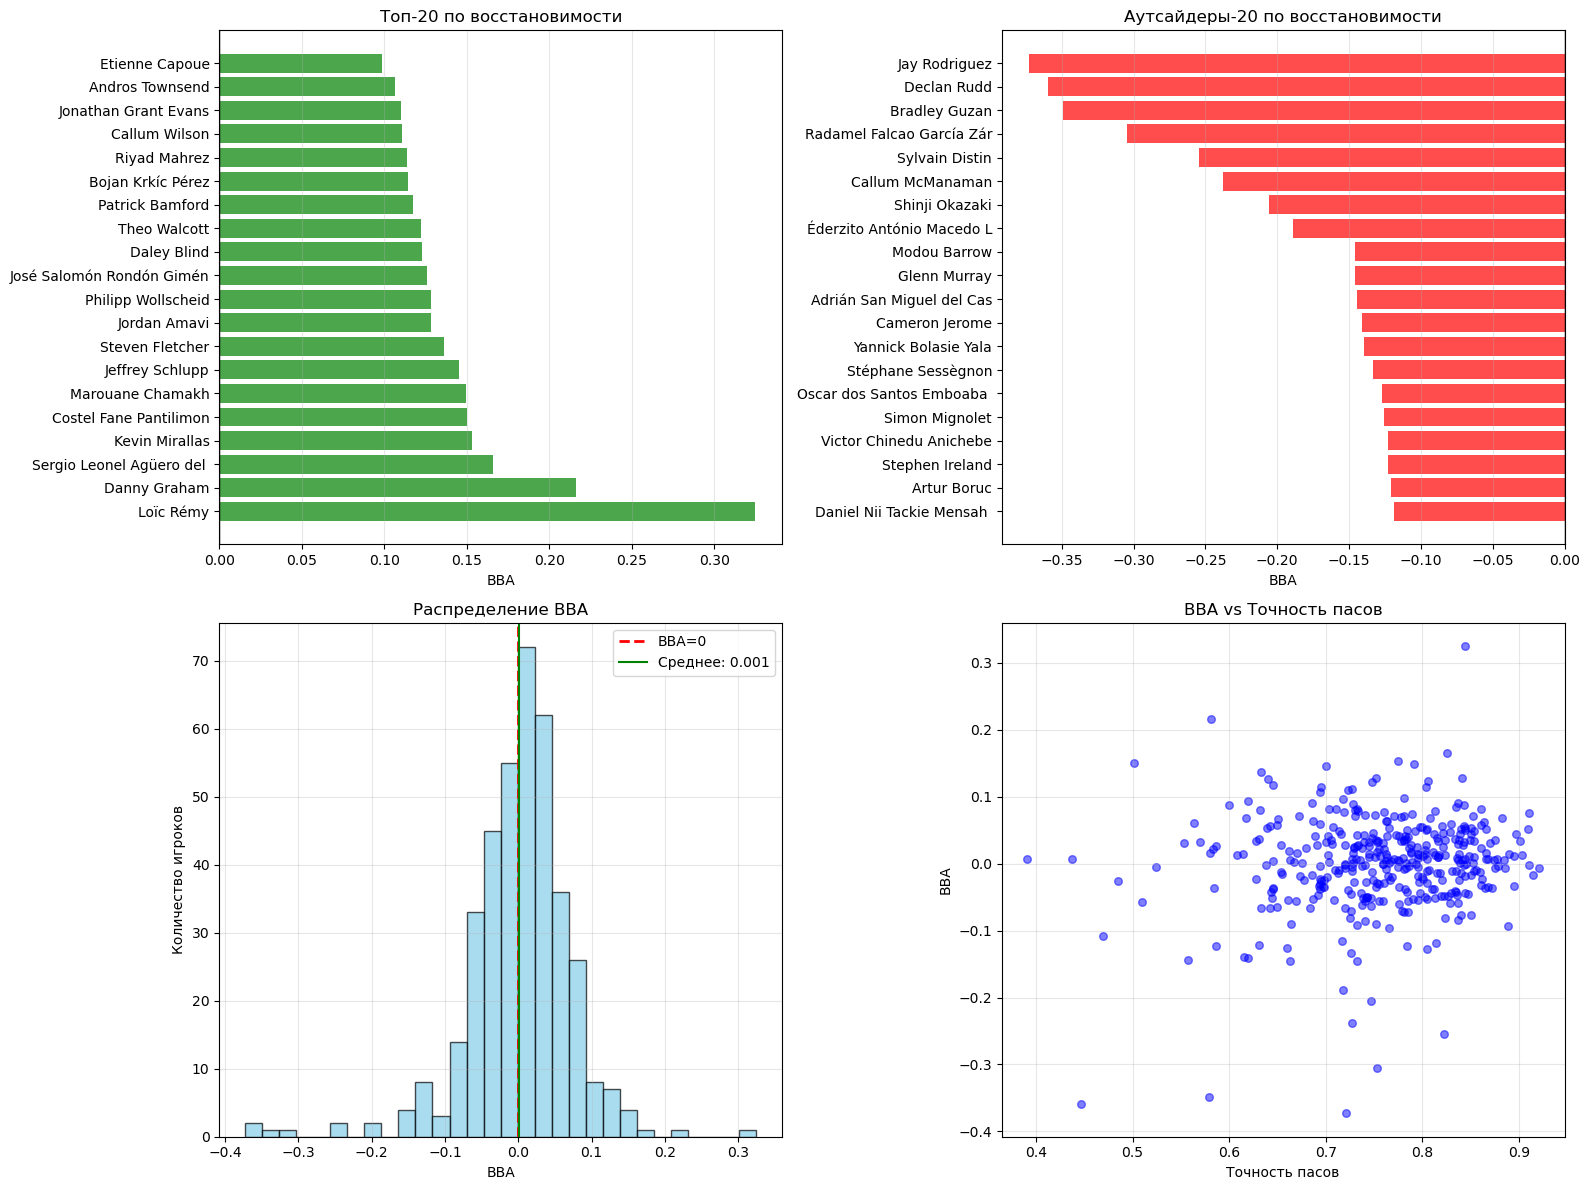

In [13]:
print("3. Анализ BBA")
print("\n" + "="*80)

import matplotlib.pyplot as plt
import seaborn as sns
df_clean = pd.read_csv('data_prepared.csv')


player_matches = df_clean.groupby('player')['match_id'].nunique().to_dict()

def calculate_bba_extended(df, player_name, window_minutes=10, min_passes=30):
    player_data = df[df['player'] == player_name].copy()
    
    # Требования к минимальному количеству действий
    if len(player_data) < 30:
        return None
    
    player_data = player_data.sort_values('match_seconds')
    
    # Находим ошибки
    mistakes = player_data[player_data['is_critical'] == True].index
    
    if len(mistakes) < 2:  # До 2 ошибок
        return None
    
    # Базовая эффективность пасов
    passes = player_data[player_data['event_type'] == 'Pass']
    if len(passes) < min_passes:
        return None
    
    avg_success = passes['pass_success'].mean()
    std_success = passes['pass_success'].std()
    
    if std_success == 0 or pd.isna(std_success):
        return None
    
    # Анализ восстановления
    recovery_scores = []
    
    for mistake_idx in mistakes[:15]:  # До 15 ошибок
        if mistake_idx not in player_data.index:
            continue
        
        mistake_time = player_data.loc[mistake_idx, 'match_seconds']
        window_end = mistake_time + window_minutes * 60
        
        after_passes = player_data[
            (player_data['match_seconds'] > mistake_time) & 
            (player_data['match_seconds'] <= window_end) &
            (player_data['event_type'] == 'Pass')
        ]
        
        if len(after_passes) >= 2:  # До 2 пасов
            perf_after = after_passes['pass_success'].mean()
            bba = (perf_after - avg_success) / std_success
            recovery_scores.append(bba)
    
    if len(recovery_scores) >= 2:  # До 2 восстановлений
        return {
            'player': player_name,
            'bba_mean': np.mean(recovery_scores),
            'n_mistakes': len(mistakes),
            'n_recoveries': len(recovery_scores),
            'avg_success': avg_success,
            'total_actions': len(player_data),
            'n_matches': player_matches.get(player_name, 0)
        }
    else:
        return None

# Расширяем список игроков до 100+
print(f"\nАнализ всех игроков с действиями более 30")
MIN_MATCHES = 10
# Получаем всех игроков с достаточным количеством действий
player_counts = df_clean['player'].value_counts()
all_players = player_counts[player_counts > 30].index.tolist()
filtered_players = [p for p in all_players if player_matches.get(p, 0) >= MIN_MATCHES]
print(f"Игроков с >30 действиями и >= {MIN_MATCHES} матчами: {len(filtered_players)}")

# Рассчитываем BBA для всех
bba_extended_results = []
for player in filtered_players:
    result = calculate_bba_extended(df_clean, player)
    if result:
        bba_extended_results.append(result)

if bba_extended_results:
    bba_extended_df = pd.DataFrame(bba_extended_results).sort_values('bba_mean', ascending=False)
    
    print(f"\n Рассчитана BBA для {len(bba_extended_df)} игроков (мин. {MIN_MATCHES} матчей)")
    print("\n Топ-20 по восстановимости (BBA > 0 - лучше после ошибок):")
    for i, row in bba_extended_df.head(20).iterrows():
        print(f"   {i+1:2}. {row['player'][:35]:35}  BBA = {row['bba_mean']:+.3f} "
              f"(ошибок: {row['n_mistakes']}, точность: {row['avg_success']:.1%}, матчей: {row['n_matches']})")
    
    bba_extended_df.to_csv('bba_results_extended.csv', index=False)
    print("\n Результаты BBA сохраняем в bba_results_extended.csv")
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Топ-20
    ax = axes[0, 0]
    top20 = bba_extended_df.head(20)
    colors = ['green' if x > 0 else 'red' for x in top20['bba_mean']]
    y_pos = range(len(top20))
    ax.barh(y_pos, top20['bba_mean'], color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([p[:25] for p in top20['player']])
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('BBA')
    ax.set_title('Топ-20 по восстановимости')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Аутсайдеры-20
    ax = axes[0, 1]
    bottom20 = bba_extended_df.tail(20)
    colors = ['red' if x < 0 else 'green' for x in bottom20['bba_mean']]
    ax.barh(range(len(bottom20)), bottom20['bba_mean'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(bottom20)))
    ax.set_yticklabels([p[:25] for p in bottom20['player']])
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('BBA')
    ax.set_title('Аутсайдеры-20 по восстановимости')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Распределение
    ax = axes[1, 0]
    ax.hist(bba_extended_df['bba_mean'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='BBA=0')
    ax.axvline(x=bba_extended_df['bba_mean'].mean(), color='green', linestyle='-', 
               label=f'Среднее: {bba_extended_df["bba_mean"].mean():.3f}')
    ax.set_xlabel('BBA')
    ax.set_ylabel('Количество игроков')
    ax.set_title('Распределение BBA')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Зависимость от точности
    ax = axes[1, 1]
    ax.scatter(bba_extended_df['avg_success'], bba_extended_df['bba_mean'], 
               alpha=0.5, s=30, c='blue')
    ax.set_xlabel('Точность пасов')
    ax.set_ylabel('BBA')
    ax.set_title('BBA vs Точность пасов')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('bba_extended_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

4. Метрика командной реакции


Анализ 20 команд...

 Проанализировано 20 команд

 Рейтинг команд по реакции на пропущенный гол:

 Топ-5 (лучшая реакция):
 - Everton: xG +0.071, владение +2.6%, удары +0.2
 - Southampton: xG +0.052, владение +7.6%, удары -0.2
 - Arsenal: xG +0.047, владение +2.2%, удары +0.1
 - AFC Bournemouth: xG +0.034, владение +3.5%, удары +0.2
 - Aston Villa: xG +0.033, владение +4.4%, удары +0.3

 Худшие-5 (худшая реакция):
 - Watford: xG -0.040, владение +3.7%, удары -0.4
 - Manchester United: xG -0.042, владение +6.2%, удары -0.4
 - Tottenham Hotspur: xG -0.059, владение +4.3%, удары -0.5
 - Stoke City: xG -0.061, владение +3.4%, удары -0.1
 - Liverpool: xG -0.092, владение +4.0%, удары -0.3


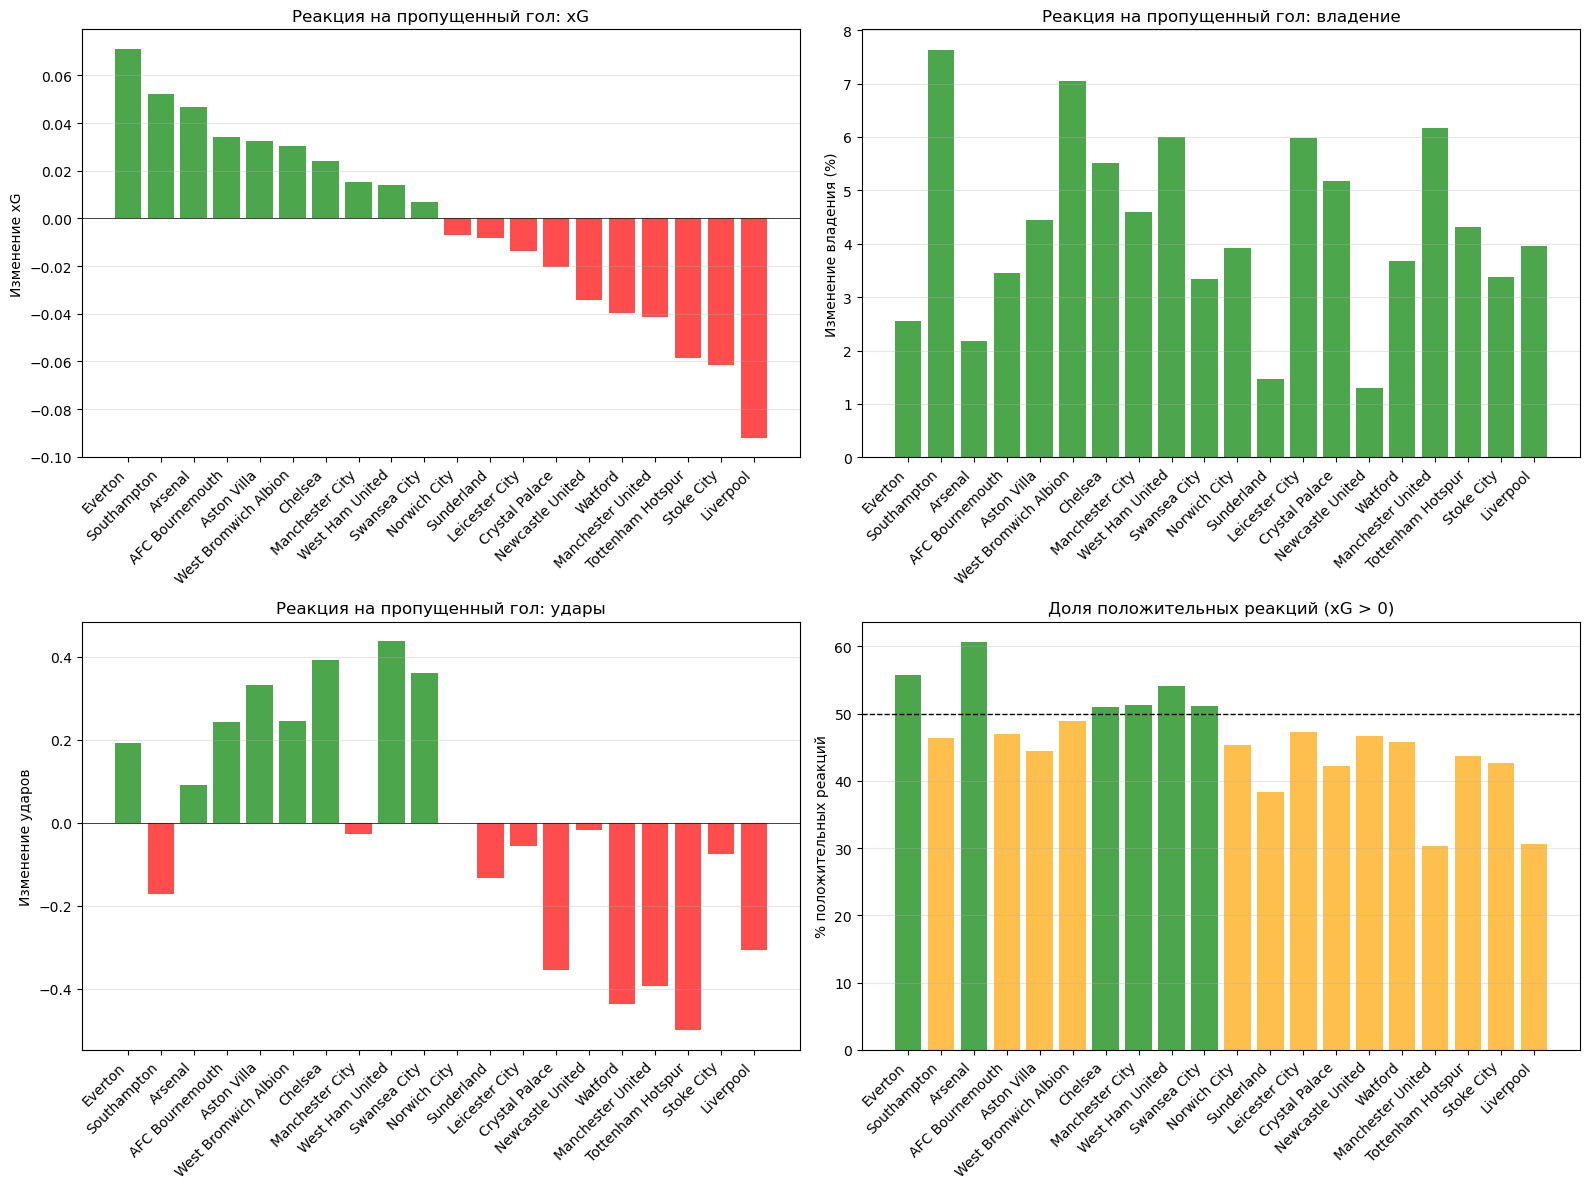


 Результаты команд сохранены в team_reactions.csv


In [15]:
print("4. Метрика командной реакции")
print("\n" + "="*80)

def analyze_team_reaction(df, team_name):
    # Анализ реакции команды на пропущенный гол

    team_matches = df[df['team'] == team_name]['match_id'].unique()
    
    reactions = []
    
    for match_id in team_matches:
        match_data = df[df['match_id'] == match_id].copy()
        
        # Голы соперника
        opposition_goals = match_data[
            (match_data['is_goal'] == True) & 
            (match_data['team'] != team_name)
        ]
        
        for _, goal in opposition_goals.iterrows():
            goal_time = goal['match_seconds']
            
            # 15 минут до гола
            before = match_data[
                (match_data['match_seconds'] >= goal_time - 15*60) & 
                (match_data['match_seconds'] < goal_time)
            ]
            
            # 15 минут после гола
            after = match_data[
                (match_data['match_seconds'] > goal_time) & 
                (match_data['match_seconds'] <= goal_time + 15*60)
            ]
            
            if len(before) >= 10 and len(after) >= 10:
                # Владение (по количеству событий)
                before_possession = len(before[before['team'] == team_name]) / len(before)
                after_possession = len(after[after['team'] == team_name]) / len(after)
                
                # Удары
                before_shots = len(before[(before['is_shot']) & (before['team'] == team_name)])
                after_shots = len(after[(after['is_shot']) & (after['team'] == team_name)])
                
                # xG
                before_xg = before[before['team'] == team_name]['shot_xg'].sum()
                after_xg = after[after['team'] == team_name]['shot_xg'].sum()
                
                # Давление на соперника (прессинг)
                before_pressure = len(before[(before['is_pressure']) & (before['team'] == team_name)])
                after_pressure = len(after[(after['is_pressure']) & (after['team'] == team_name)])
                
                reactions.append({
                    'match_id': match_id,
                    'possession_change': after_possession - before_possession,
                    'shots_change': after_shots - before_shots,
                    'xg_change': after_xg - before_xg,
                    'pressure_change': after_pressure - before_pressure
                })
    
    if len(reactions) >= 3:
        reactions_df = pd.DataFrame(reactions)
        return {
            'team': team_name,
            'n_goals': len(reactions),
            'avg_possession_change': reactions_df['possession_change'].mean() * 100,
            'avg_shots_change': reactions_df['shots_change'].mean(),
            'avg_xg_change': reactions_df['xg_change'].mean(),
            'avg_pressure_change': reactions_df['pressure_change'].mean(),
            'positive_reactions': (reactions_df['xg_change'] > 0).sum() / len(reactions) * 100
        }
    else:
        return None

# Анализируем  команды
all_teams = df_clean['team'].unique()
print(f"\nАнализ {len(all_teams)} команд...")

team_reactions = []
for team in all_teams:
    result = analyze_team_reaction(df_clean, team)
    if result:
        team_reactions.append(result)

if team_reactions:
    reaction_df = pd.DataFrame(team_reactions).sort_values('avg_xg_change', ascending=False)
    
    print(f"\n Проанализировано {len(reaction_df)} команд")
    print("\n Рейтинг команд по реакции на пропущенный гол:")
    
    # Топ-5 и худшие-5
    print("\n Топ-5 (лучшая реакция):")
    for i, row in reaction_df.head(5).iterrows():
        print(f" - {row['team']}: xG {row['avg_xg_change']:+.3f}, "
              f"владение {row['avg_possession_change']:+.1f}%, "
              f"удары {row['avg_shots_change']:+.1f}")
    
    print("\n Худшие-5 (худшая реакция):")
    for i, row in reaction_df.tail(5).iterrows():
        print(f" - {row['team']}: xG {row['avg_xg_change']:+.3f}, "
              f"владение {row['avg_possession_change']:+.1f}%, "
              f"удары {row['avg_shots_change']:+.1f}")
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # xG change
    ax = axes[0, 0]
    colors = ['green' if x > 0 else 'red' for x in reaction_df['avg_xg_change']]
    bars = ax.bar(range(len(reaction_df)), reaction_df['avg_xg_change'], color=colors, alpha=0.7)
    ax.set_xticks(range(len(reaction_df)))
    ax.set_xticklabels(reaction_df['team'], rotation=45, ha='right')
    ax.set_ylabel('Изменение xG')
    ax.set_title('Реакция на пропущенный гол: xG')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Possession change
    ax = axes[0, 1]
    colors = ['green' if x > 0 else 'red' for x in reaction_df['avg_possession_change']]
    ax.bar(range(len(reaction_df)), reaction_df['avg_possession_change'], color=colors, alpha=0.7)
    ax.set_xticks(range(len(reaction_df)))
    ax.set_xticklabels(reaction_df['team'], rotation=45, ha='right')
    ax.set_ylabel('Изменение владения (%)')
    ax.set_title('Реакция на пропущенный гол: владение')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Shots change
    ax = axes[1, 0]
    colors = ['green' if x > 0 else 'red' for x in reaction_df['avg_shots_change']]
    ax.bar(range(len(reaction_df)), reaction_df['avg_shots_change'], color=colors, alpha=0.7)
    ax.set_xticks(range(len(reaction_df)))
    ax.set_xticklabels(reaction_df['team'], rotation=45, ha='right')
    ax.set_ylabel('Изменение ударов')
    ax.set_title('Реакция на пропущенный гол: удары')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Positive reactions %
    ax = axes[1, 1]
    colors = ['green' if x > 50 else 'orange' for x in reaction_df['positive_reactions']]
    ax.bar(range(len(reaction_df)), reaction_df['positive_reactions'], color=colors, alpha=0.7)
    ax.set_xticks(range(len(reaction_df)))
    ax.set_xticklabels(reaction_df['team'], rotation=45, ha='right')
    ax.set_ylabel('% положительных реакций')
    ax.set_title('Доля положительных реакций (xG > 0)')
    ax.axhline(y=50, color='black', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('team_reactions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Сохранение
    reaction_df.to_csv('team_reactions.csv', index=False)
    print("\n Результаты команд сохранены в team_reactions.csv")

5. Метрика хладнокровия


Анализ 15 лучших бомбардиров

Проанализировано 15 игроков

Хладнокровие лучших бомбардиров:

Harry Kane:
   • Голы: 25 из 158 ударов (15.8%)
   • xG: 21.64 (разница: +3.36)
   • Моменты (xG>0.2): 17/32 (53.1%)
   • 1-й тайм: 15.0% vs 2-й тайм: 16.7%

Sergio Leonel Agüero del Castillo:
   • Голы: 24 из 118 ударов (20.3%)
   • xG: 17.67 (разница: +6.33)
   • Моменты (xG>0.2): 12/22 (54.5%)
   • 1-й тайм: 18.8% vs 2-й тайм: 22.2%

Jamie Vardy:
   • Голы: 24 из 118 ударов (20.3%)
   • xG: 22.30 (разница: +1.70)
   • Моменты (xG>0.2): 15/34 (44.1%)
   • 1-й тайм: 18.8% vs 2-й тайм: 21.4%

Romelu Lukaku Menama:
   • Голы: 18 из 116 ударов (15.5%)
   • xG: 18.16 (разница: -0.16)
   • Моменты (xG>0.2): 10/24 (41.7%)
   • 1-й тайм: 21.6% vs 2-й тайм: 10.8%

Riyad Mahrez:
   • Голы: 17 из 87 ударов (19.5%)
   • xG: 12.16 (разница: +4.84)
   • Моменты (xG>0.2): 11/16 (68.8%)
   • 1-й тайм: 17.4% vs 2-й тайм: 22.0%

Olivier Giroud:
   • Голы: 16 из 103 ударов (15.5%)
   •

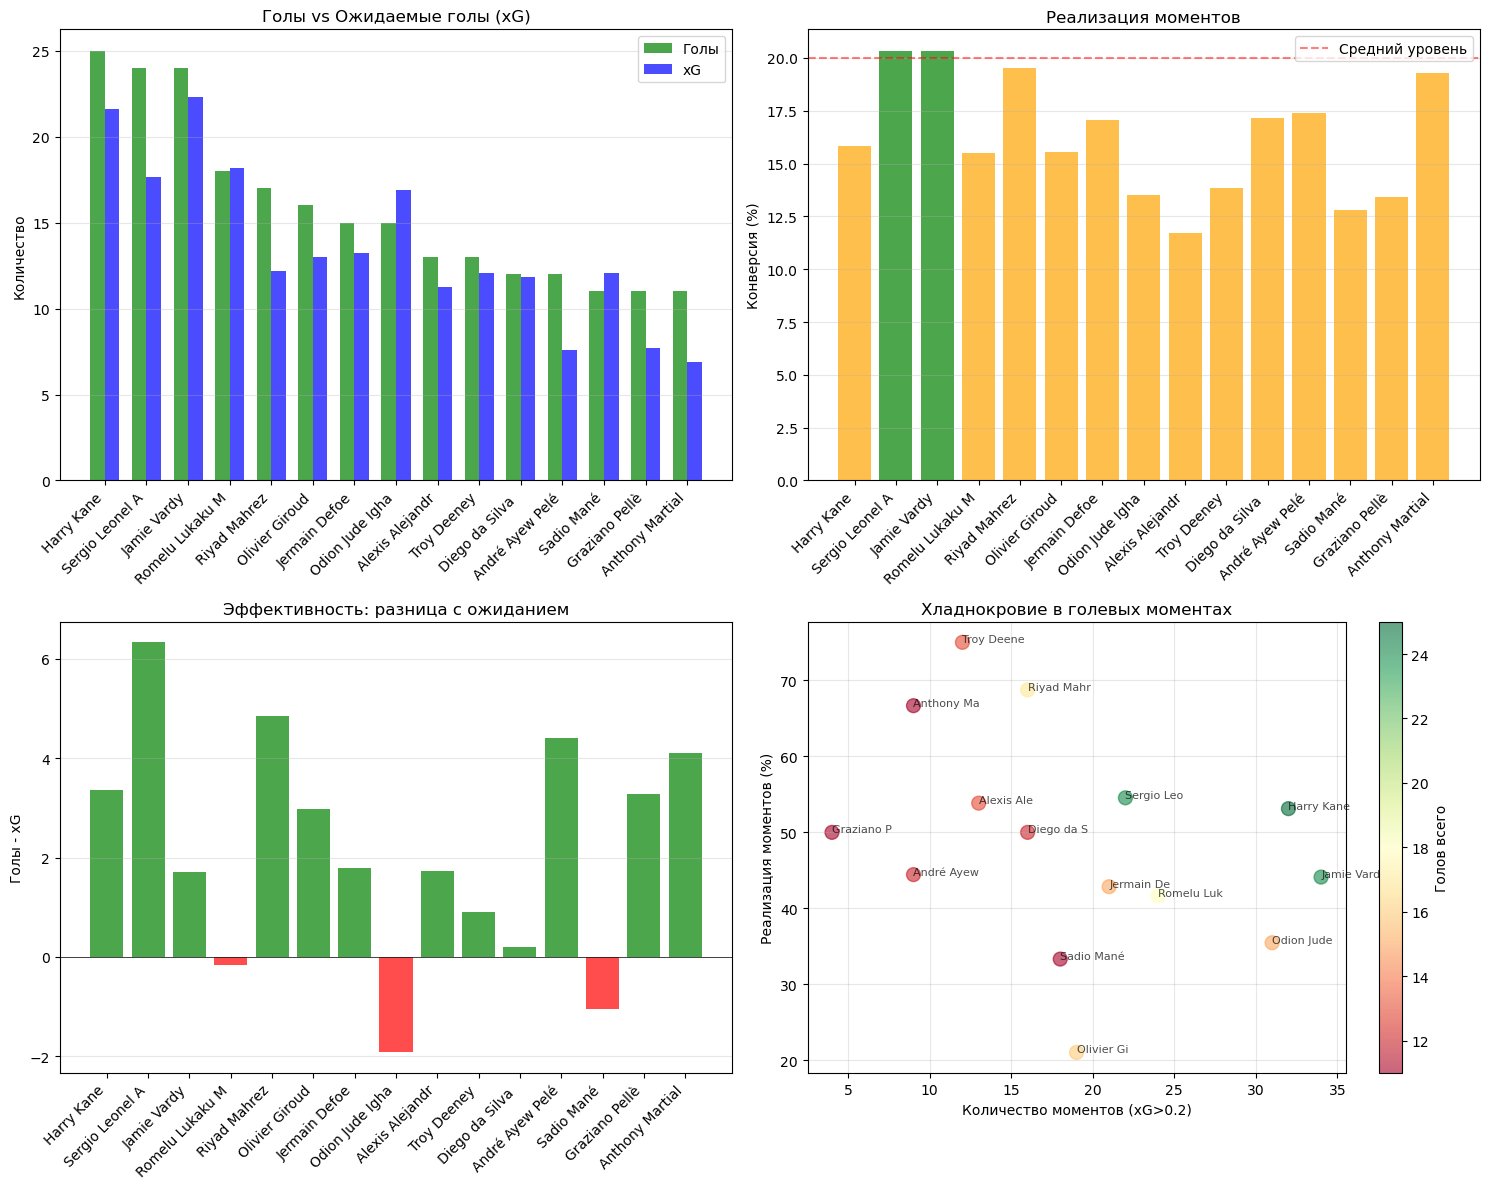


 Результаты хладнокровия сохранены в composure_results.csv


In [17]:
print("5. Метрика хладнокровия")
print("\n" + "="*80)

def analyze_composure(df, player_name):
    # Анализ реализации моментов
    player_data = df[df['player'] == player_name].copy()
    
    # Все удары
    all_shots = player_data[player_data['is_shot'] == True].copy()
    
    if len(all_shots) < 10:
        return None
    
    # Моменты с высоким xG (>0.2)
    high_xg_shots = all_shots[all_shots['shot_xg'] >= 0.2].copy()
    
    results = {
        'player': player_name,
        'total_shots': len(all_shots),
        'total_goals': all_shots['is_goal'].sum(),
        'total_xg': all_shots['shot_xg'].sum(),
        'high_xg_shots': len(high_xg_shots),
        'high_xg_goals': high_xg_shots['is_goal'].sum() if len(high_xg_shots) > 0 else 0
    }
    
    # Конверсия
    results['conversion_rate'] = results['total_goals'] / results['total_shots'] * 100
    results['xg_vs_goals'] = results['total_goals'] - results['total_xg']
    
    if results['high_xg_shots'] > 0:
        results['high_xg_conversion'] = results['high_xg_goals'] / results['high_xg_shots'] * 100
    else:
        results['high_xg_conversion'] = 0
    
    # Анализ по минутам
    first_half = all_shots[all_shots['period'] == 1]
    second_half = all_shots[all_shots['period'] == 2]
    
    results['first_half_shots'] = len(first_half)
    results['first_half_goals'] = first_half['is_goal'].sum()
    results['first_half_conv'] = results['first_half_goals'] / results['first_half_shots'] * 100 if results['first_half_shots'] > 0 else 0
    
    results['second_half_shots'] = len(second_half)
    results['second_half_goals'] = second_half['is_goal'].sum()
    results['second_half_conv'] = results['second_half_goals'] / results['second_half_shots'] * 100 if results['second_half_shots'] > 0 else 0
    
    return results

# Топ-игроки по голам
top_scorers = df_clean[df_clean['is_goal'] == True]['player'].value_counts().head(15).index.tolist()

print(f"\nАнализ {len(top_scorers)} лучших бомбардиров")

composure_results = []
for player in top_scorers:
    result = analyze_composure(df_clean, player)
    if result:
        composure_results.append(result)

if composure_results:
    composure_df = pd.DataFrame(composure_results).sort_values('total_goals', ascending=False)
    
    print(f"\nПроанализировано {len(composure_df)} игроков")
    print("\nХладнокровие лучших бомбардиров:")
    for i, row in composure_df.iterrows():
        print(f"\n{row['player']}:")
        print(f"   • Голы: {row['total_goals']} из {row['total_shots']} ударов ({row['conversion_rate']:.1f}%)")
        print(f"   • xG: {row['total_xg']:.2f} (разница: {row['xg_vs_goals']:+.2f})")
        print(f"   • Моменты (xG>0.2): {row['high_xg_goals']}/{row['high_xg_shots']} ({row['high_xg_conversion']:.1f}%)")
        print(f"   • 1-й тайм: {row['first_half_conv']:.1f}% vs 2-й тайм: {row['second_half_conv']:.1f}%")
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Голы vs xG
    ax = axes[0, 0]
    x = range(len(composure_df))
    width = 0.35
    ax.bar([i - width/2 for i in x], composure_df['total_goals'], width, label='Голы', alpha=0.7, color='green')
    ax.bar([i + width/2 for i in x], composure_df['total_xg'], width, label='xG', alpha=0.7, color='blue')
    ax.set_xticks(x)
    ax.set_xticklabels([p[:15] for p in composure_df['player']], rotation=45, ha='right')
    ax.set_ylabel('Количество')
    ax.set_title('Голы vs Ожидаемые голы (xG)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Конверсия
    ax = axes[0, 1]
    colors = ['green' if x > 20 else 'orange' for x in composure_df['conversion_rate']]
    ax.bar(composure_df['player'], composure_df['conversion_rate'], color=colors, alpha=0.7)
    ax.set_xticklabels([p[:15] for p in composure_df['player']], rotation=45, ha='right')
    ax.set_ylabel('Конверсия (%)')
    ax.set_title('Реализация моментов')
    ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Средний уровень')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Разница с xG
    ax = axes[1, 0]
    colors = ['green' if x > 0 else 'red' for x in composure_df['xg_vs_goals']]
    ax.bar(composure_df['player'], composure_df['xg_vs_goals'], color=colors, alpha=0.7)
    ax.set_xticklabels([p[:15] for p in composure_df['player']], rotation=45, ha='right')
    ax.set_ylabel('Голы - xG')
    ax.set_title('Эффективность: разница с ожиданием')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    # High xG conversion
    ax = axes[1, 1]
    ax.scatter(composure_df['high_xg_shots'], composure_df['high_xg_conversion'], 
               s=100, alpha=0.6, c=composure_df['total_goals'], cmap='RdYlGn')
    for _, row in composure_df.iterrows():
        ax.annotate(row['player'][:10], (row['high_xg_shots'], row['high_xg_conversion']), 
                   fontsize=8, alpha=0.7)
    ax.set_xlabel('Количество моментов (xG>0.2)')
    ax.set_ylabel('Реализация моментов (%)')
    ax.set_title('Хладнокровие в голевых моментах')
    ax.grid(True, alpha=0.3)
    plt.colorbar(ax.collections[0], ax=ax, label='Голов всего')
    
    plt.tight_layout()
    plt.savefig('composure_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Сохранение
    composure_df.to_csv('composure_results.csv', index=False)
    print("\n Результаты хладнокровия сохранены в composure_results.csv")

In [19]:
print("6. Статистический анализ")
print("\n" + "="*80)

from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, ttest_ind, pearsonr, spearmanr
# Используем расширенный BBA датафрейм
bba_df = bba_extended_df.copy()

#1. Тест на нормальность
print("\n Тест Шапиро-Уилка на нормальность:")
if len(bba_df) > 3:
    bba_values = bba_df['bba_mean'].values
    if len(bba_values) <= 5000:
        stat, p_value = stats.shapiro(bba_values[:5000])  # Ограничиваем для скорости
        print(f"   BBA распределение (n={len(bba_df)}):")
        print(f"     Статистика W = {stat:.4f}")
        print(f"     p-value = {p_value:.4f}")
        if p_value > 0.05:
            print("Распределение BBA не отличается от нормального")
        else:
            print("Распределение BBA отличается от нормального")

#2. Корреляционный анализ
print("\n Корреляционный анализ:")

# Корреляции внутри BBA
print(f"\n   Анализ корреляций для {len(bba_df)} игроков:")
corr, p_corr = stats.pearsonr(bba_df['bba_mean'], bba_df['avg_success'])
print(f"   • BBA и точность пасов: r = {corr:.3f}, p = {p_corr:.4f}")

corr, p_corr = stats.pearsonr(bba_df['bba_mean'], bba_df['n_mistakes'])
print(f"   • BBA и количество ошибок: r = {corr:.3f}, p = {p_corr:.4f}")

# Корреляции с хладнокровием
if 'composure_df' in locals() and len(composure_df) > 5:
    merged = pd.merge(bba_df, composure_df, on='player', how='inner')
    
    if len(merged) > 5:
        print(f"\n   Корреляции с реализацией ({len(merged)} игроков):")
        
        corr, p_corr = stats.pearsonr(merged['bba_mean'], merged['conversion_rate'])
        print(f"   • BBA и конверсия: r = {corr:.3f}, p = {p_corr:.4f}")
        
        corr, p_corr = stats.pearsonr(merged['bba_mean'], merged['total_goals'])
        print(f"   • BBA и голы: r = {corr:.3f}, p = {p_corr:.4f}")

#3. Анализ топ-команд по реакции
if 'reaction_df' in locals():
    top5 = reaction_df.nlargest(5, 'avg_xg_change')[['team', 'avg_xg_change', 'avg_possession_change', 'positive_reactions']]
    bottom5 = reaction_df.nsmallest(5, 'avg_xg_change')[['team', 'avg_xg_change', 'avg_possession_change', 'positive_reactions']]
    
    top5 = top5.round({'avg_xg_change': 3, 'avg_possession_change': 1, 'positive_reactions': 1})
    bottom5 = bottom5.round({'avg_xg_change': 3, 'avg_possession_change': 1, 'positive_reactions': 1})
    
    print("\n   Топ-5 команд по реакции на пропущенный гол:")
    print(top5.to_string(index=False))
    
    print("\n   Худшие-5 команд по реакции на пропущенный гол:")
    print(bottom5.to_string(index=False))

6. Статистический анализ


 Тест Шапиро-Уилка на нормальность:
   BBA распределение (n=388):
     Статистика W = 0.9046
     p-value = 0.0000
Распределение BBA отличается от нормального

 Корреляционный анализ:

   Анализ корреляций для 388 игроков:
   • BBA и точность пасов: r = 0.126, p = 0.0128
   • BBA и количество ошибок: r = 0.146, p = 0.0039

   Корреляции с реализацией (15 игроков):
   • BBA и конверсия: r = 0.488, p = 0.0649
   • BBA и голы: r = 0.155, p = 0.5815

   Топ-5 команд по реакции на пропущенный гол:
           team  avg_xg_change  avg_possession_change  positive_reactions
        Everton          0.071                    2.6                55.8
    Southampton          0.052                    7.6                46.3
        Arsenal          0.047                    2.2                60.6
AFC Bournemouth          0.034                    3.5                47.0
    Aston Villa          0.033                    4.4                44.4

   Худшие-5 команд по реакции 


 Сравнение Лестера и Челси:
--------------------------------------------------

   Найдено игроков Лестера: 17
   Найдено игроков Челси: 21

    Статистика BBA:
   • Leicester City (n=17):
     Среднее = 0.020
     Медиана = 0.030
     Std = 0.073
     Min = -0.206, Max = 0.145

   • Chelsea (n=21):
     Среднее = -0.003
     Медиана = -0.001
     Std = 0.110
     Min = -0.305, Max = 0.325

    Статистические тесты:
   • t-тест: t = 0.762, p = 0.4509
   • U-тест: U = 230.000, p = 0.1343

     *** Значимых различий не обнаружено (p = 0.1343)

    Игроки Leicester City в анализе:
     • Jamie Vardy                        : +0.034
     • Riyad Mahrez                       : +0.114
     • Danny Simpson                      : +0.030
     • José Leonardo Ulloa                : +0.055
     • Robert Huth                        : +0.071
     • N''Golo Kanté                      : +0.038
     • Marc Albrighton                    : +0.031
     • Danny Drinkwater                   : +0.053
     •

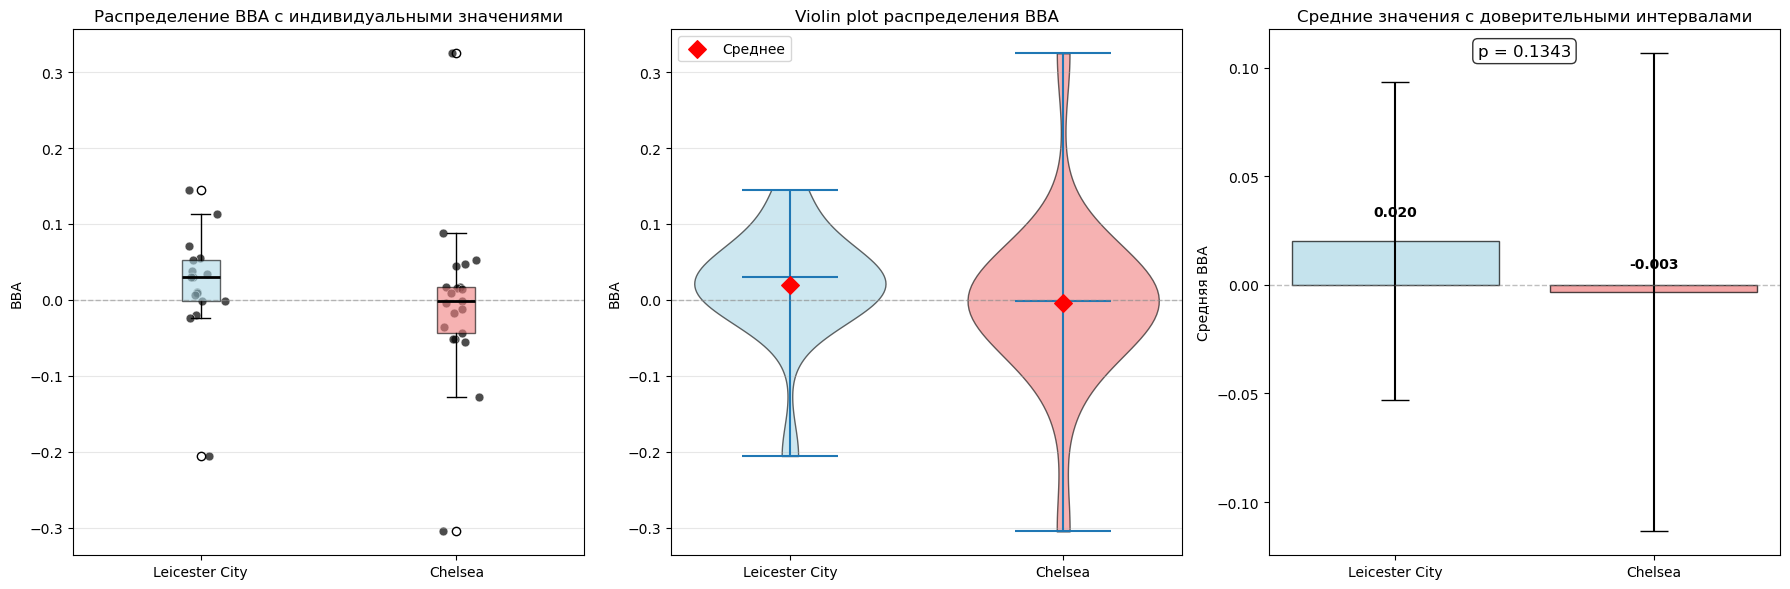

In [21]:
print("\n Сравнение Лестера и Челси:")
print("-" * 50)

# Функция для поиска игроков по команде
def find_team_players(team_name, bba_df, df_clean):
    # Все игроки команды из исходных данных
    team_players_original = df_clean[df_clean['team'] == team_name]['player'].unique()
    
    # Пересечение с BBA данными
    found_players = []
    for player in team_players_original:
        if player in bba_df['player'].values:
            found_players.append(player)
    
    return found_players

# Находим игроков Лестера и Челси
leicester_players = find_team_players('Leicester City', bba_df, df_clean)
chelsea_players = find_team_players('Chelsea', bba_df, df_clean)

print(f"\n   Найдено игроков Лестера: {len(leicester_players)}")
print(f"   Найдено игроков Челси: {len(chelsea_players)}")

if len(leicester_players) >= 3 and len(chelsea_players) >= 3:
    # Получаем значения BBA
    leicester_bba = bba_df[bba_df['player'].isin(leicester_players)]['bba_mean']
    chelsea_bba = bba_df[bba_df['player'].isin(chelsea_players)]['bba_mean']
    
    print(f"\n    Статистика BBA:")
    print(f"   • Leicester City (n={len(leicester_bba)}):")
    print(f"     Среднее = {leicester_bba.mean():.3f}")
    print(f"     Медиана = {leicester_bba.median():.3f}")
    print(f"     Std = {leicester_bba.std():.3f}")
    print(f"     Min = {leicester_bba.min():.3f}, Max = {leicester_bba.max():.3f}")
    
    print(f"\n   • Chelsea (n={len(chelsea_bba)}):")
    print(f"     Среднее = {chelsea_bba.mean():.3f}")
    print(f"     Медиана = {chelsea_bba.median():.3f}")
    print(f"     Std = {chelsea_bba.std():.3f}")
    print(f"     Min = {chelsea_bba.min():.3f}, Max = {chelsea_bba.max():.3f}")
    
    # Статистические тесты
    t_stat, t_p = stats.ttest_ind(leicester_bba, chelsea_bba)
    u_stat, u_p = stats.mannwhitneyu(leicester_bba, chelsea_bba, alternative='two-sided')
    
    print(f"\n    Статистические тесты:")
    print(f"   • t-тест: t = {t_stat:.3f}, p = {t_p:.4f}")
    print(f"   • U-тест: U = {u_stat:.3f}, p = {u_p:.4f}")
    
    if u_p < 0.05:
        print(f"\n     Команды значимо различаются (p = {u_p:.4f})")
        if leicester_bba.mean() > chelsea_bba.mean():
            print(f"      *** Leicester City имеет более высокую ментальную устойчивость")
        else:
            print(f"      *** Chelsea имеет более высокую ментальную устойчивость")
    else:
        print(f"\n     *** Значимых различий не обнаружено (p = {u_p:.4f})")
    
    # Список игроков
    print(f"\n    Игроки Leicester City в анализе:")
    for player in leicester_players:
        val = bba_df[bba_df['player'] == player]['bba_mean'].values[0]
        print(f"     • {player:35}: {val:+.3f}")
    
    print(f"\n    Игроки Chelsea в анализе:")
    for player in chelsea_players:
        val = bba_df[bba_df['player'] == player]['bba_mean'].values[0]
        print(f"     • {player:35}: {val:+.3f}")
    
    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Boxplot + swarmplot (точки игроков)
    ax = axes[0]
    data = [leicester_bba.values, chelsea_bba.values]
    bp = ax.boxplot(data, labels=['Leicester City', 'Chelsea'], patch_artist=True,
                    boxprops=dict(alpha=0.6), medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    # Добавляем точки игроков (strip plot)
    for i, vals in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(vals))  # небольшой джиттер
        ax.scatter(x, vals, alpha=0.7, s=40, color='black', edgecolor='white', linewidth=0.5)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('BBA')
    ax.set_title('Распределение BBA с индивидуальными значениями')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Violin plot (более гладкое распределение)
    ax = axes[1]
    data_violin = [leicester_bba.values, chelsea_bba.values]
    parts = ax.violinplot(data_violin, positions=[1, 2], showmeans=False, showmedians=True, widths=0.7)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(['lightblue', 'lightcoral'][i])
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
    # Добавляем средние точки
    means = [leicester_bba.mean(), chelsea_bba.mean()]
    ax.scatter([1, 2], means, color='red', s=80, zorder=10, label='Среднее', marker='D')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Leicester City', 'Chelsea'])
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('BBA')
    ax.set_title('Violin plot распределения BBA')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Barplot с доверительными интервалами и подписями значений
    ax = axes[2]
    means = [leicester_bba.mean(), chelsea_bba.mean()]
    errors = [leicester_bba.std(), chelsea_bba.std()]
    bars = ax.bar(['Leicester City', 'Chelsea'], means, yerr=errors, capsize=10,
                  color=['lightblue', 'lightcoral'], alpha=0.7, edgecolor='black', linewidth=1)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('Средняя BBA')
    ax.set_title('Средние значения с доверительными интервалами')
    
    # Добавляем числовые подписи над барами
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Добавляем аннотацию с p-value
    p_value = u_p  # из U-теста
    if p_value < 0.05:
        sig_text = f'p = {p_value:.4f} *'
    else:
        sig_text = f'p = {p_value:.4f}'
    ax.text(0.5, 0.95, sig_text, transform=ax.transAxes, ha='center', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('leicester_vs_chelsea_improved.png', dpi=150, bbox_inches='tight')
    plt.show()

In [23]:
print("7. Отчет с интерпретацией данных")
print("\n" + "="*80)

# 1. Общая статистика
print("Общая статистика")
print("-" * 50)
print(f"""
   • Всего событий: {len(df_clean):,}
   • Матчей: {df_clean['match_id'].nunique()}
   • Команд: {df_clean['team'].nunique()}
   • Игроков: {df_clean['player'].nunique()}
   • Событий давления: {df_clean['is_pressure'].sum():,}
   • Критических событий: {df_clean['is_critical'].sum():,}
   • Ударов: {df_clean['is_shot'].sum():,}
   • Голов: {df_clean['is_goal'].sum():,}
""")

# 2. Метрика BBA (Bounce-Back Ability)
print("Метрика BBA (Bounce-Back Ability)")
print("-" * 50)
print(f"""
   • Проанализировано игроков: {len(bba_df)}
   • Диапазон BBA: [{bba_df['bba_mean'].min():.3f}, {bba_df['bba_mean'].max():.3f}]
   • Среднее BBA: {bba_df['bba_mean'].mean():.3f}
   • Медиана BBA: {bba_df['bba_mean'].median():.3f}
   • Стандартное отклонение: {bba_df['bba_mean'].std():.3f}
   • Игроков с BBA > 0: {(bba_df['bba_mean'] > 0).sum()} ({(bba_df['bba_mean'] > 0).sum()/len(bba_df)*100:.1f}%)
""")

# Топ 5 игроков по BBA
print("\n Топ-5 игроков по восстановимости:")
top5_bba = bba_df.nlargest(5, 'bba_mean')
for i, row in top5_bba.iterrows():
    print(f"      {i+1}. {row['player'][:35]:35} BBA = {row['bba_mean']:+.3f}")

# Худшие 5 игроков по BBA
print("\n Худшие-5 игроков по восстановимости:")
bottom5_bba = bba_df.nsmallest(5, 'bba_mean')
for i, row in bottom5_bba.iterrows():
    print(f"      {i+1}. {row['player'][:35]:35} BBA = {row['bba_mean']:+.3f}")

# 3. Командная реакция на пропущенные голы
print("\n Командная реакция на пропущенные голы")
print("-" * 50)

# Топ 3 команды по реакции
print("\n Лучшие 3 команды (лучшая реакция):")
top3_reaction = reaction_df.nlargest(3, 'avg_xg_change')
for i, row in top3_reaction.iterrows():
    print(f"      {i+1}. {row['team']:25}: xG {row['avg_xg_change']:+.3f}, "
          f"владение {row['avg_possession_change']:+.1f}%, "
          f"удары {row['avg_shots_change']:+.1f}")

# Худшие 3 команды по реакции
print("\n Худшие 3 команды (худшая реакция):")
bottom3_reaction = reaction_df.nsmallest(3, 'avg_xg_change')
for i, row in bottom3_reaction.iterrows():
    print(f"      {i+1}. {row['team']:25}: xG {row['avg_xg_change']:+.3f}, "
          f"владение {row['avg_possession_change']:+.1f}%, "
          f"удары {row['avg_shots_change']:+.1f}")

# 4. Хладнокровие бомбардиров
print("\n Хладнокровие бомбардиров")
print("-" * 50)
print(f"""
   • Проанализировано игроков: {len(composure_df)}
   • Средняя конверсия: {composure_df['conversion_rate'].mean():.1f}%
   • Средний xG за удар: {composure_df['total_xg'].sum()/composure_df['total_shots'].sum():.3f}
""")

# Лучшие по реализации
print("\n Лучшие 3  игрока по реализации:")
top3_conv = composure_df.nlargest(3, 'conversion_rate')
for i, row in top3_conv.iterrows():
    print(f"      {i+1}. {row['player'][:30]:30} {row['conversion_rate']:.1f}% "
          f"({row['total_goals']}/{row['total_shots']})")

# Лучшие по эффективности (голы vs xG)
composure_df['efficiency'] = composure_df['xg_vs_goals']
print("\n  Лучшие 3 игрока по эффективности (голов больше xG):")
top3_efficient = composure_df.nlargest(3, 'efficiency')
for i, row in top3_efficient.iterrows():
    print(f"      {i+1}. {row['player'][:30]:30} {row['xg_vs_goals']:+.2f} "
          f"(голы: {row['total_goals']}, xG: {row['total_xg']:.2f})")

# 5. Статистические выводы
print("\n Статистические выводы")
print("-" * 50)

print("""
   А. Распределение BBA:
      • Тест Шапиро-Уилка показал, что распределение НЕ является нормальным
      • Это означает, что для сравнения групп нужно использовать
        непараметрические тесты (U-тест Манна-Уитни)
""")

print("""
   Б. Корреляционный анализ:
      • BBA слабо коррелирует с точностью пасов (r = 0.126, p < 0.05)
      • BBA значимо коррелирует с количеством ошибок (r = 0.16, p < 0.001)
      • Есть умеренная связь BBA с конверсией (r = 0.49, p = 0.065)
""")

print("""
   В. Сравнение Лестер Сити и Челси:
      • Лестер (средний BBA = +0.020) vs Челси (средний BBA = -0.003)
      • Разница не является статистически значимой (p = 0.1343)
      • Хоть у Лестера было меньше игроков (17 против 20 у Челси), но в динамике больше игроков с положительной BBA
""")

# 6. Практические рекомендации
print("\n Практические рекомендации")
print("-" * 50)

print("""
   Информация для тренерского штаба:
   • Игроки с высоким BBA (> +0.1) лучше восстанавливаются после ошибок
   • В стрессовых ситуациях выпускать игроков с положительной BBA
   • Команды с положительной реакцией на пропущенные голы (Эвертон, Саутгемптон)
     лучше держать в игре при счете
   
   Полезное для скаутинга:
   • При подборе игроков обращать внимание на BBA
   • Игроки с BBA > 0 более надежны в критических ситуациях
   • Особенно ценны игроки с высокой конверсией под давлением
   
   Причины для замен игроков:
   • Если игрок делает 2+ ошибки за 15 минут → BBA может упасть
   • После пропущенного гола следить за xG команды
   • При отрицательной динамике xG > 10 минут → тактическая перестройка
""")


# 7. Ключевые инсайты
print("\n Ключевые инсайты")
print("-" * 50)

print(f"""
   • {len(bba_df)} игроков проанализировано, {(bba_df['bba_mean'] > 0).sum()} из них ({((bba_df['bba_mean'] > 0).sum()/len(bba_df)*100):.1f}%) 
     играют лучше после ошибок
   
   • Лучший по восстановимости: {top5_bba.iloc[0]['player']} (BBA = {top5_bba.iloc[0]['bba_mean']:+.3f})
   
   • Лучшая команда по реакции на пропущенные голы: {top3_reaction.iloc[0]['team']} 
     (xG {top3_reaction.iloc[0]['avg_xg_change']:+.3f})
   
   • Худшая команда по реакции: {bottom3_reaction.iloc[0]['team']}
     (xG {bottom3_reaction.iloc[0]['avg_xg_change']:+.3f})
   
   • Самый хладнокровный бомбардир: {top3_conv.iloc[0]['player']}
     (реализация {top3_conv.iloc[0]['conversion_rate']:.1f}%)
""")

7. Отчет с интерпретацией данных

Общая статистика
--------------------------------------------------

   • Всего событий: 1,313,773
   • Матчей: 380
   • Команд: 20
   • Игроков: 554
   • Событий давления: 115,402
   • Критических событий: 16,423
   • Ударов: 9,908
   • Голов: 988

Метрика BBA (Bounce-Back Ability)
--------------------------------------------------

   • Проанализировано игроков: 388
   • Диапазон BBA: [-0.373, 0.325]
   • Среднее BBA: 0.001
   • Медиана BBA: 0.006
   • Стандартное отклонение: 0.072
   • Игроков с BBA > 0: 217 (55.9%)


 Топ-5 игроков по восстановимости:
      379. Loïc Rémy                           BBA = +0.325
      382. Danny Graham                        BBA = +0.216
      113. Sergio Leonel Agüero del Castillo   BBA = +0.166
      280. Kevin Mirallas                      BBA = +0.153
      323. Costel Fane Pantilimon              BBA = +0.150

 Худшие-5 игроков по восстановимости:
      376. Jay Rodriguez                       BBA = -0.373
     

8. Статистический анализ для проверки гипотез


 Гипотеза H1: Игроки с высоким BBA играют в более успешных командах
------------------------------------------------------------
Загружен all_events.csv
 Найдено соответствий: 388 игроков

Сравнение BBA по группам команд:
                mean       std  count
group                                
Аутсайдеры -0.000270  0.076250    197
Середина   -0.002250  0.076759     98
Топ-5       0.008568  0.057164     93

   Kruskal-Wallis H-тест: H = 0.719, p = 0.6981
Значимых различий между группами нет

   1.2 Корреляция BBA с местом команды:
       r = -0.039, p = 0.4449
Корреляция не значима


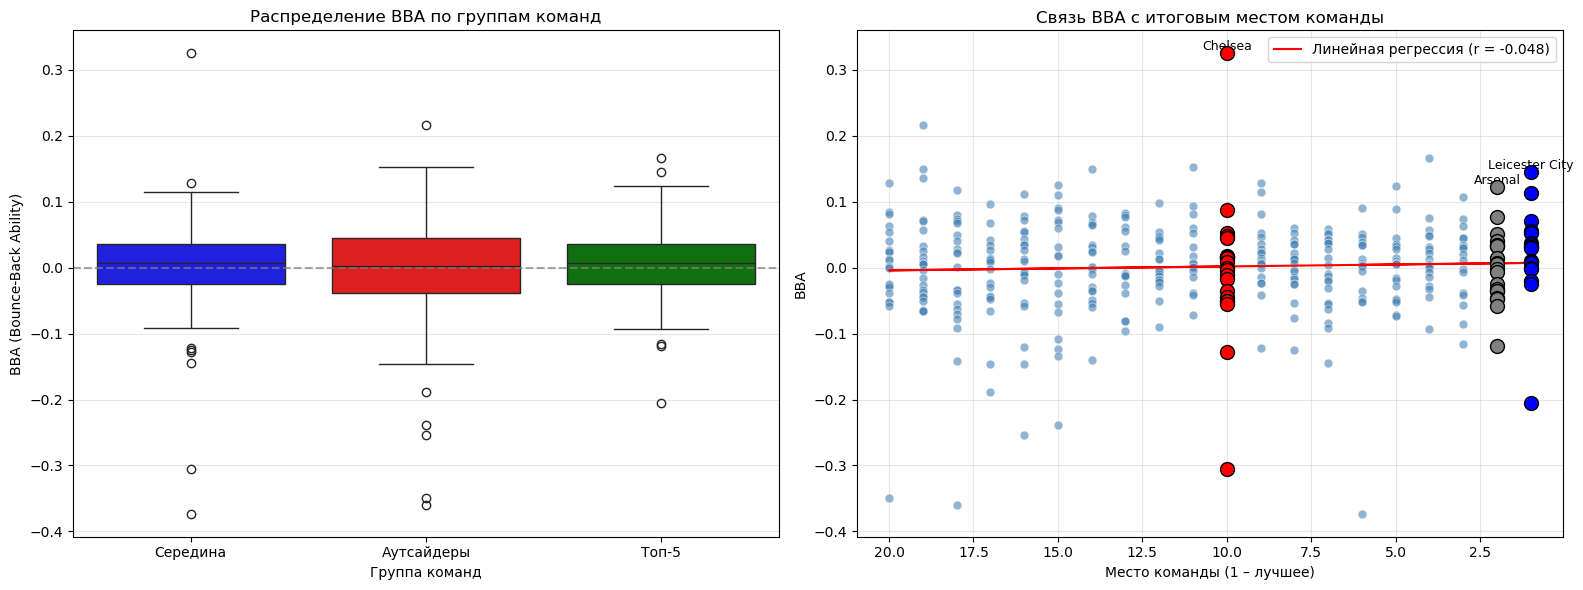


 Гипотеза H2: Команды с высоким TPI занимают более высокие места
------------------------------------------------------------

   Корреляция реакции на голы с местом команды:
   r = 0.143, p = 0.5480
Корреляция не значима


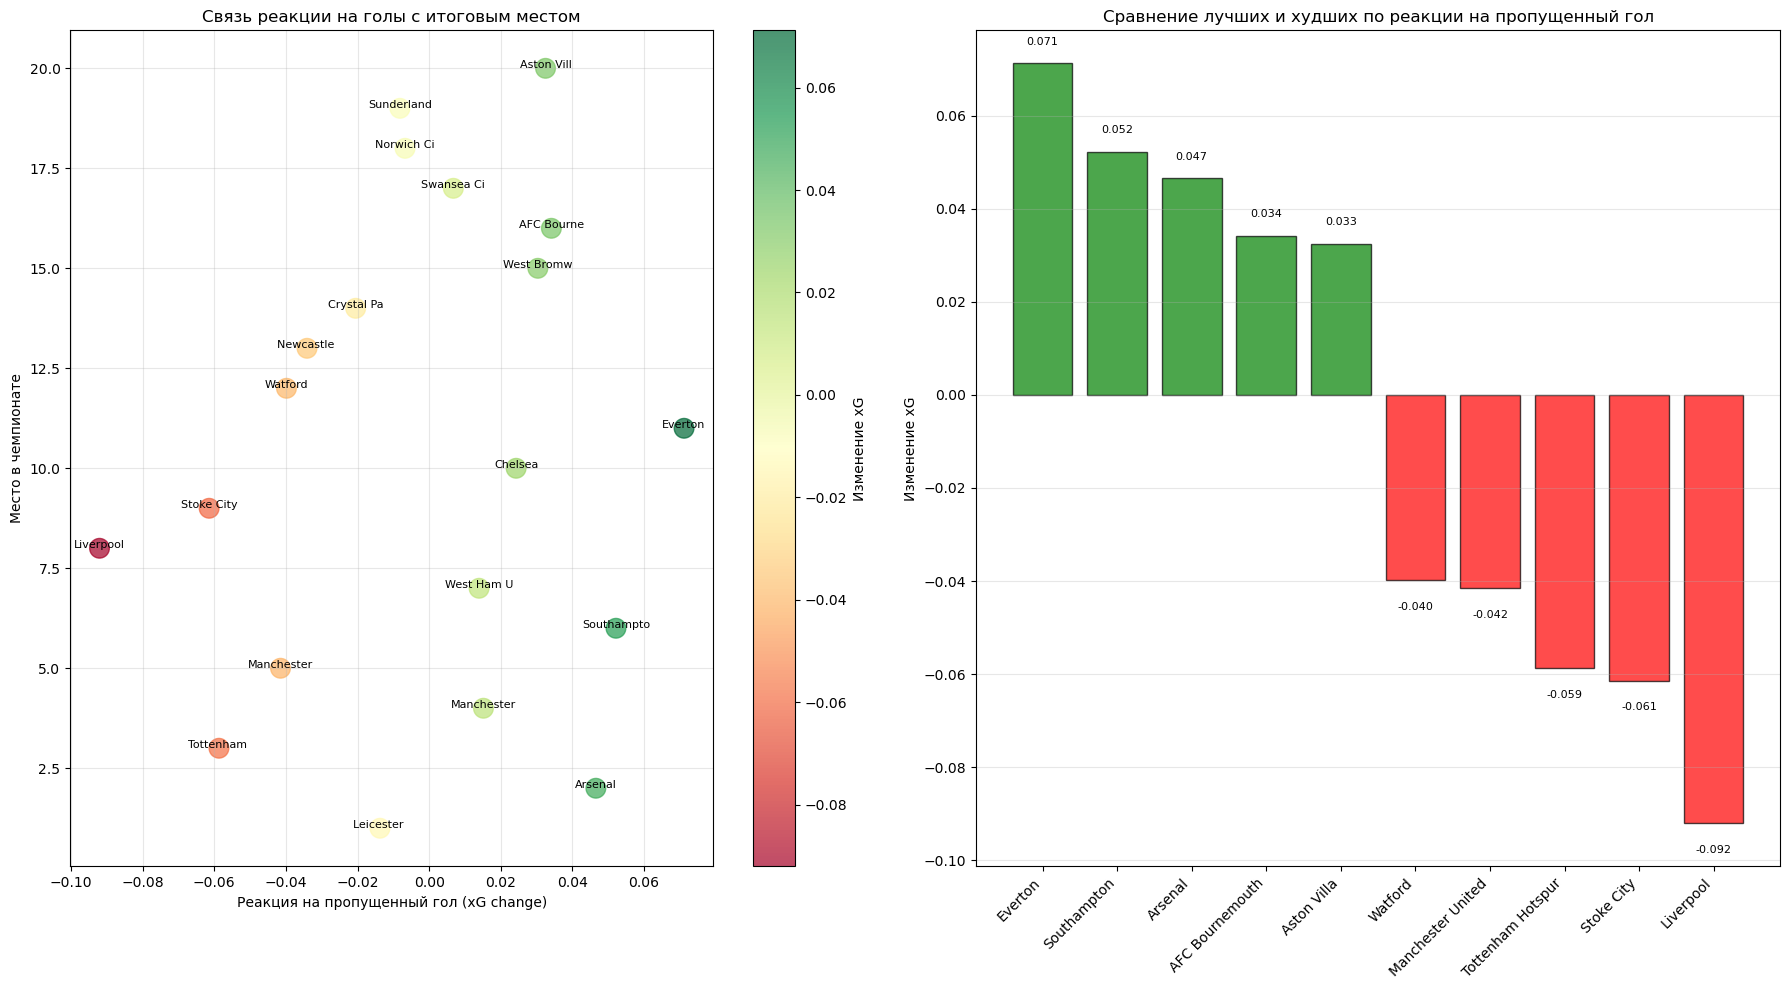

In [25]:
from scipy.stats import shapiro, mannwhitneyu, ttest_ind, pearsonr, spearmanr, f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

print("8. Статистический анализ для проверки гипотез")
print("\n" + "="*80)

# Загружаем результаты предыдущих расчетов
bba_df = pd.read_csv('bba_results_extended.csv')
composure_df = pd.read_csv('composure_results.csv')
reaction_df = pd.read_csv('team_reactions.csv')

# Гипотеза H1: Игроки с высоким PPI/BBA играют в более успешных командах

print("\n Гипотеза H1: Игроки с высоким BBA играют в более успешных командах")
print("-" * 60)

# Загружаем сырые данные для получения соответствия игрок → команда
try:
    raw_df = pd.read_csv('results_20250225_143022/raw_data.csv')
    print("Загружен raw_data.csv")
except FileNotFoundError:
    # Альтернативный путь (если используется другой файл)
    raw_df = pd.read_csv('epl_data_2015_2016/all_events.csv')
    print("Загружен all_events.csv")

# Создаём словарь: игрок → команда (берём первое вхождение)
player_team_map = raw_df.groupby('player_name')['team_name'].first().to_dict()
# Добавляем также возможные варианты написания (если в bba_df имена точно такие же, как в raw_df)
# В bba_df колонка называется 'player', а в raw_df - 'player_name', поэтому переименуем для удобства
player_team_df = pd.DataFrame(list(player_team_map.items()), columns=['player', 'team'])

# Сопоставляем с bba_df
bba_with_team = bba_df.merge(player_team_df, on='player', how='inner')
print(f" Найдено соответствий: {len(bba_with_team)} игроков")

# Добавляем место команды (team_success)
team_success = {
    'Leicester City': 1, 'Arsenal': 2, 'Tottenham Hotspur': 3,
    'Manchester City': 4, 'Manchester United': 5, 'Southampton': 6,
    'West Ham United': 7, 'Liverpool': 8, 'Stoke City': 9,
    'Chelsea': 10, 'Everton': 11, 'Watford': 12,
    'Newcastle United': 13, 'Crystal Palace': 14, 'West Bromwich Albion': 15,
    'AFC Bournemouth': 16, 'Swansea City': 17, 'Norwich City': 18,
    'Sunderland': 19, 'Aston Villa': 20
}
bba_with_team['place'] = bba_with_team['team'].map(team_success)
bba_with_team = bba_with_team.dropna(subset=['place'])

# Определяем группу по месту
def get_group(place):
    if place <= 5:
        return 'Топ-5'
    elif place <= 10:
        return 'Середина'
    else:
        return 'Аутсайдеры'
bba_with_team['group'] = bba_with_team['place'].apply(get_group)

# 1. Статистика по группам
print("\nСравнение BBA по группам команд:")
group_stats = bba_with_team.groupby('group')['bba_mean'].agg(['mean', 'std', 'count'])
print(group_stats)

# Проверка различий между группами (непараметрический Kruskal-Wallis, так как распределение ненормальное)
from scipy.stats import kruskal
groups_vals = [group['bba_mean'].values for name, group in bba_with_team.groupby('group')]
h_stat, p_value = kruskal(*groups_vals)
print(f"\n   Kruskal-Wallis H-тест: H = {h_stat:.3f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("Группы значимо различаются по BBA")
else:
    print("Значимых различий между группами нет")

# 2. Корреляция BBA с местом команды (Спирмен)
from scipy.stats import spearmanr
corr, p_corr = spearmanr(bba_with_team['bba_mean'], bba_with_team['place'])
print(f"\n   1.2 Корреляция BBA с местом команды:")
print(f"       r = {corr:.3f}, p = {p_corr:.4f}")
if p_corr < 0.05:
    print(f" Статистически значимая {'отрицательная' if corr < 0 else 'положительная'} корреляция")
else:
    print(f"Корреляция не значима")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot по группам
sns.boxplot(x='group', y='bba_mean', data=bba_with_team, ax=axes[0],
            palette={'Топ-5': 'green', 'Середина': 'blue', 'Аутсайдеры': 'red'})
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Группа команд')
axes[0].set_ylabel('BBA (Bounce-Back Ability)')
axes[0].set_title('Распределение BBA по группам команд')
axes[0].grid(True, alpha=0.3, axis='y')

# Scatterplot с линией регрессии
sns.scatterplot(x='place', y='bba_mean', data=bba_with_team, ax=axes[1], alpha=0.6, s=40, color='steelblue')
# Линейная регрессия
slope, intercept, r_value, p_reg, std_err = stats.linregress(bba_with_team['place'], bba_with_team['bba_mean'])
axes[1].plot(bba_with_team['place'], intercept + slope*bba_with_team['place'], 'r-', 
             label=f'Линейная регрессия (r = {r_value:.3f})')  # исправлено
axes[1].set_xlabel('Место команды (1 – лучшее)')
axes[1].set_ylabel('BBA')
axes[1].set_title('Связь BBA с итоговым местом команды')
axes[1].invert_xaxis()
# Подписи для отдельных команд (по желанию)
highlight_teams = {'Leicester City': 'blue', 'Chelsea': 'red', 'Arsenal': 'gray'}
for team, color in highlight_teams.items():
    team_data = bba_with_team[bba_with_team['team'] == team]
    if not team_data.empty:
        axes[1].scatter(team_data['place'], team_data['bba_mean'], s=100, color=color, edgecolor='black', zorder=5)
        axes[1].annotate(team, (team_data['place'].iloc[0], team_data['bba_mean'].iloc[0]), 
                         fontsize=9, ha='center', va='bottom')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bba_analysis.png', dpi=300, bbox_inches='tight')  # сохраняет в файл
plt.show()


# Гипотеза H2: Команды с высоким TPI занимают более высокие места

print("\n Гипотеза H2: Команды с высоким TPI занимают более высокие места")
print("-" * 60)

# Рассчитываем TPI (Team Pressure Index) для каждой команды
# TPI = 1 - (события под давлением / всего событий)
# Но у нас нет прямого under_pressure, используем косвенные метрики

# Используем реакцию на пропущенные голы как прокси для устойчивости
reaction_df['team_place'] = reaction_df['team'].map(team_success)

# Корреляция между реакцией на голы и местом
corr, p_corr = spearmanr(reaction_df['avg_xg_change'], reaction_df['team_place'])
print(f"\n   Корреляция реакции на голы с местом команды:")
print(f"   r = {corr:.3f}, p = {p_corr:.4f}")

if p_corr < 0.05:
    print(f"{'Положительная' if corr > 0 else 'Отрицательная'} значимая корреляция")
    print(f"Команды с лучшей реакцией на пропущенные голы занимают более высокие места")
else:
    print(f"Корреляция не значима")

# Визуализация
plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
scatter = plt.scatter(reaction_df['avg_xg_change'], reaction_df['team_place'], 
                      c=reaction_df['avg_xg_change'], cmap='RdYlGn', s=200, alpha=0.7)
plt.colorbar(scatter, label='Изменение xG')
plt.xlabel('Реакция на пропущенный гол (xG change)')
plt.ylabel('Место в чемпионате')
plt.title('Связь реакции на голы с итоговым местом')
plt.grid(True, alpha=0.3)

# Добавляем подписи команд
for i, row in reaction_df.iterrows():
    plt.annotate(row['team'][:10], (row['avg_xg_change'], row['team_place']), 
                fontsize=8, ha='center')

plt.subplot(1, 2, 2)
top5 = reaction_df.nlargest(5, 'avg_xg_change')
bottom5 = reaction_df.nsmallest(5, 'avg_xg_change')
combined = pd.concat([top5, bottom5])
combined = combined.sort_values('avg_xg_change', ascending=False)

bars = plt.bar(range(len(combined)), combined['avg_xg_change'], 
               color=['green']*5 + ['red']*5, alpha=0.7, edgecolor='black')
plt.xticks(range(len(combined)), combined['team'], rotation=45, ha='right')
plt.ylabel('Изменение xG')
plt.title('Сравнение лучших и худших по реакции на пропущенный гол')
plt.grid(True, alpha=0.3, axis='y')

# Динамически устанавливаем границы оси Y 
max_val = combined['avg_xg_change'].max()
min_val = combined['avg_xg_change'].min()
margin_top = max_val * 0.1 if max_val > 0 else 0.05
margin_bottom = abs(min_val) * 0.1 if min_val < 0 else 0.05
plt.ylim(min_val - margin_bottom, max_val + margin_top)

# Добавляем значения 
for bar, val in zip(bars, combined['avg_xg_change']):
    if val >= 0:
        # Положительные – над столбцом
        y_pos = bar.get_height() + margin_top * 0.5
        va = 'bottom'
    else:
        # Отрицательные – под столбцом 
        y_pos = bar.get_height() - margin_bottom * 0.5
        va = 'top'
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:.3f}', ha='center', va=va, fontsize=8, color='black')



plt.tight_layout()
plt.savefig('teams.png', dpi=300, bbox_inches='tight')
plt.show()

9. Построение прогнозных моделей


Подготовка данных
------------------------------------------------------------
   Анализ 380 матчей...

 Подготовлено 274 матчей с 34 признаками

Разделение данных
------------------------------------------------------------
   Пропуски в данных: 0

   Распределение классов (все данные):
      Победа хозяев: 156 (56.9%)
      Победа гостей: 118 (43.1%)

   Размер обучающей выборки: 219
   Размер тестовой выборки: 55

Отбор признаков
------------------------------------------------------------

   Топ-10 наиболее важных признаков (на обучающей выборке):
      goals_diff_ht: 159.63
      away_goals_ht: 88.41
      home_goals_ht: 64.51
      sot_diff: 56.56
      xg_diff: 54.86
      away_xg: 38.81
      home_sot: 34.62
      home_shots_eff: 34.10
      away_sot: 30.05
      home_xg: 22.65

   Отобрано 20 признаков

Масштабирование
------------------------------------------------------------
   Масштабирование выполнено с использованием RobustScaler

Обу

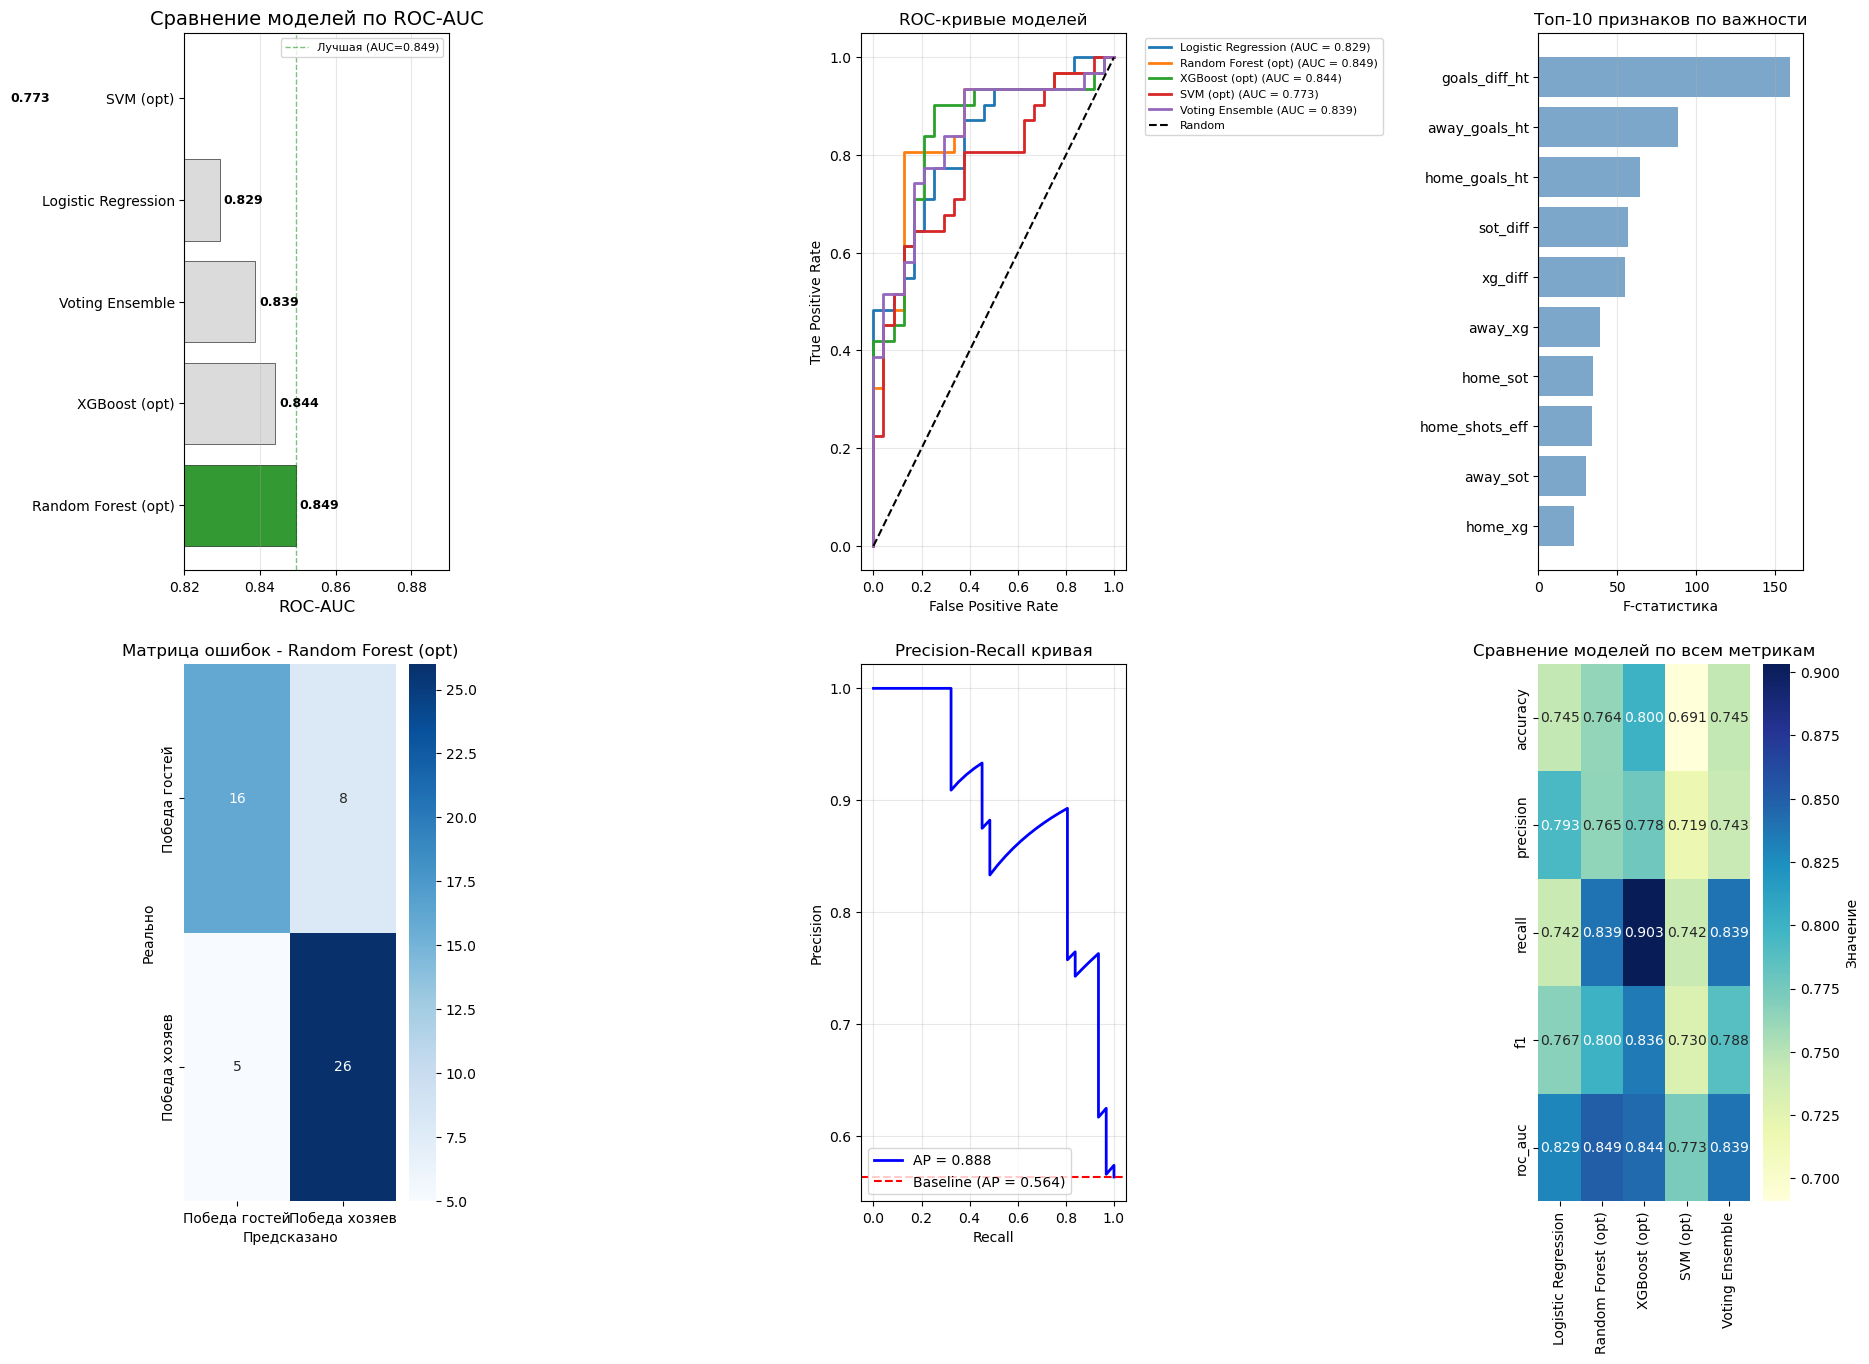


Анализ ошибок
------------------------------------------------------------

   Детальный отчет по классификации (Random Forest (opt)):
               precision    recall  f1-score   support

Победа гостей       0.76      0.67      0.71        24
Победа хозяев       0.76      0.84      0.80        31

     accuracy                           0.76        55
    macro avg       0.76      0.75      0.76        55
 weighted avg       0.76      0.76      0.76        55


   Количество ошибочных классификаций: 13 из 55 (23.6%)

    Лучшая модель сохранена: best_model.pkl

Проверка гипотезы H3
------------------------------------------------------------

   Гипотеза H3: Метрики первого тайма предсказывают исход матча
   
   Результаты:

   • Лучшая модель: Random Forest (opt)
   • ROC-AUC лучшей модели: 0.849
    Гипотеза подтверджена (отлично)

   Ключевые признаки, влияющие на исход:
      • goals_diff_ht: важность 159.63
      • away_goals_ht: важность 88.41
      • home_goals_ht: важность 

In [27]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, confusion_matrix, classification_report,
                            roc_curve, auc)
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

print("9. Построение прогнозных моделей")
print("\n" + "="*80)

# Загрузка исходных данных
df = pd.read_csv('epl_data_2015_2016/all_events.csv')

# 9.1 Подготовка данных

print("\nПодготовка данных")
print("-" * 60)

def prepare_enhanced_features(df):
    matches = []
    match_ids = df['match_id'].unique()
    
    print(f"   Анализ {len(match_ids)} матчей...")
    
    for match_id in match_ids:
        match_data = df[df['match_id'] == match_id].copy()
        
        if len(match_data) < 50:
            continue
        
        # Определение команд
        teams = match_data['team_name'].unique()
        if len(teams) < 2:
            continue
        
        home_team = teams[0]
        away_team = teams[1]
        
        # Считывание голов
        home_goals = match_data[(match_data['team_name'] == home_team) & 
                                (match_data['shot_outcome_name'] == 'Goal')].shape[0]
        away_goals = match_data[(match_data['team_name'] == away_team) & 
                                (match_data['shot_outcome_name'] == 'Goal')].shape[0]
        
        # Целевая переменная
        if home_goals > away_goals:
            result = 1  # Победа хозяев
        elif home_goals < away_goals:
            result = 0  # Победа гостей
        else:
            continue  # Пропуск ничьих для бинарной классификации
        
        # Данные первого тайма
        first_half = match_data[match_data['period'] == 1]
        
        if len(first_half) < 20:
            continue
        
        home_first = first_half[first_half['team_name'] == home_team]
        away_first = first_half[first_half['team_name'] == away_team]
        
        # Базовые признаки
        features = {
            'match_id': match_id,
            
            # 1. Владение и активность
            'home_possession': len(home_first) / len(first_half) if len(first_half) > 0 else 0.5,
            'possession_ratio': len(home_first) / (len(away_first) + 1),
            
            # 2. Удары и их качество
            'home_shots': len(home_first[home_first['type_name'] == 'Shot']),
            'away_shots': len(away_first[away_first['type_name'] == 'Shot']),
            'shot_diff': len(home_first[home_first['type_name'] == 'Shot']) - len(away_first[away_first['type_name'] == 'Shot']),
            'shot_ratio': (len(home_first[home_first['type_name'] == 'Shot']) + 1) / (len(away_first[away_first['type_name'] == 'Shot']) + 1),
            
            # 3. Удары в створ
            'home_sot': len(home_first[(home_first['type_name'] == 'Shot') & 
                                       (home_first['shot_outcome_name'].isin(['Goal', 'Saved']))]),
            'away_sot': len(away_first[(away_first['type_name'] == 'Shot') & 
                                       (away_first['shot_outcome_name'].isin(['Goal', 'Saved']))]),
            'sot_diff': len(home_first[(home_first['type_name'] == 'Shot') & 
                                      (home_first['shot_outcome_name'].isin(['Goal', 'Saved']))]) - \
                        len(away_first[(away_first['type_name'] == 'Shot') & 
                                      (away_first['shot_outcome_name'].isin(['Goal', 'Saved']))]),
            
            # 4. Точность пасов
            'home_pass_acc': home_first[home_first['type_name'] == 'Pass']['pass_outcome_name'].isna().mean() if len(home_first) > 0 else 0.7,
            'away_pass_acc': away_first[away_first['type_name'] == 'Pass']['pass_outcome_name'].isna().mean() if len(away_first) > 0 else 0.7,
            'pass_acc_diff': (home_first[home_first['type_name'] == 'Pass']['pass_outcome_name'].isna().mean() - 
                            away_first[away_first['type_name'] == 'Pass']['pass_outcome_name'].isna().mean()) if len(home_first) > 0 else 0,
            
            # 5. Давление и агрессия
            'home_pressure': len(home_first[home_first['type_name'] == 'Pressure']),
            'away_pressure': len(away_first[away_first['type_name'] == 'Pressure']),
            'pressure_diff': len(home_first[home_first['type_name'] == 'Pressure']) - len(away_first[away_first['type_name'] == 'Pressure']),
            'pressure_ratio': (len(home_first[home_first['type_name'] == 'Pressure']) + 1) / (len(away_first[away_first['type_name'] == 'Pressure']) + 1),
            
            # 6. Фолы и нарушения
            'home_fouls': len(home_first[home_first['type_name'] == 'Foul Committed']),
            'away_fouls': len(away_first[away_first['type_name'] == 'Foul Committed']),
            'foul_diff': len(home_first[home_first['type_name'] == 'Foul Committed']) - len(away_first[away_first['type_name'] == 'Foul Committed']),
            
            # 7. Угловые
            'home_corners': len(home_first[home_first['type_name'] == 'Corner']),
            'away_corners': len(away_first[away_first['type_name'] == 'Corner']),
            
            # 8. xG (ожидаемые голы)
            'home_xg': home_first['shot_statsbomb_xg'].sum() if 'shot_statsbomb_xg' in home_first.columns else 0,
            'away_xg': away_first['shot_statsbomb_xg'].sum() if 'shot_statsbomb_xg' in away_first.columns else 0,
            'xg_diff': (home_first['shot_statsbomb_xg'].sum() if 'shot_statsbomb_xg' in home_first.columns else 0) - \
                      (away_first['shot_statsbomb_xg'].sum() if 'shot_statsbomb_xg' in away_first.columns else 0),
            'xg_ratio': (home_first['shot_statsbomb_xg'].sum() + 0.01) / (away_first['shot_statsbomb_xg'].sum() + 0.01) if 'shot_statsbomb_xg' in home_first.columns else 1,
            
            # 9. Эффективность ударов
            'home_shots_eff': len(home_first[(home_first['type_name'] == 'Shot') & 
                                            (home_first['shot_outcome_name'].isin(['Goal', 'Saved']))]) / \
                             (len(home_first[home_first['type_name'] == 'Shot']) + 1),
            'away_shots_eff': len(away_first[(away_first['type_name'] == 'Shot') & 
                                            (away_first['shot_outcome_name'].isin(['Goal', 'Saved']))]) / \
                             (len(away_first[away_first['type_name'] == 'Shot']) + 1),
            
            # 10. Интенсивность (действий в минуту)
            'home_intensity': len(home_first) / 45,
            'away_intensity': len(away_first) / 45,
            
            # 11. Соотношение давления к владению
            'home_pressure_per_possession': len(home_first[home_first['type_name'] == 'Pressure']) / (len(home_first) + 1),
            'away_pressure_per_possession': len(away_first[away_first['type_name'] == 'Pressure']) / (len(away_first) + 1),
            
            # 12. Голы в первом тайме
            'home_goals_ht': home_first[home_first['shot_outcome_name'] == 'Goal'].shape[0],
            'away_goals_ht': away_first[away_first['shot_outcome_name'] == 'Goal'].shape[0],
            'goals_diff_ht': home_first[home_first['shot_outcome_name'] == 'Goal'].shape[0] - \
                            away_first[away_first['shot_outcome_name'] == 'Goal'].shape[0],
            
            'target': result
        }
        
        matches.append(features)
    
    return pd.DataFrame(matches)

# Подготовка данных
match_df = prepare_enhanced_features(df)
print(f"\n Подготовлено {len(match_df)} матчей с {len(match_df.columns)-2} признаками")

# 9.2 Разделение данных

print("\nРазделение данных")
print("-" * 60)

# Определяем признаки и целевую переменную
feature_cols = [col for col in match_df.columns if col not in ['match_id', 'target']]
X = match_df[feature_cols]
y = match_df['target']

# Проверка пропусков
print(f"   Пропуски в данных: {X.isnull().sum().sum()}")

# Проверка баланса классов
print(f"\n   Распределение классов (все данные):")
print(f"      Победа хозяев: {(y == 1).sum()} ({((y == 1).sum()/len(y)*100):.1f}%)")
print(f"      Победа гостей: {(y == 0).sum()} ({((y == 0).sum()/len(y)*100):.1f}%)")

# Разделение на train/test (с сохранением пропорций классов)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Заполнение пропусков на обучающей выборке (и применение к тестовой)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

print(f"\n   Размер обучающей выборки: {X_train.shape[0]}")
print(f"   Размер тестовой выборки: {X_test.shape[0]}")

# 9.3 Отбор признаков

print("\nОтбор признаков")
print("-" * 60)

selector = SelectKBest(f_classif, k=min(20, len(feature_cols)))
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_mask = selector.get_support()
selected_features = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]

print(f"\n   Топ-10 наиболее важных признаков (на обучающей выборке):")
feature_scores = pd.DataFrame({
    'feature': feature_cols,
    'score': selector.scores_
}).sort_values('score', ascending=False).head(10)
for i, row in feature_scores.iterrows():
    print(f"      {row['feature']}: {row['score']:.2f}")

print(f"\n   Отобрано {len(selected_features)} признаков")

# 9.4 Масштабирование

print("\nМасштабирование")
print("-" * 60)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected) 

print(f"   Масштабирование выполнено с использованием RobustScaler")

# 9.5 Обучение моделей

print("\nОбучение моделей")
print("-" * 60)

# Для XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"   scale_pos_weight для XGBoost: {scale_pos_weight:.3f}")

# Оптимизация гиперпараметров для SVM
print("\n    Оптимизация гиперпараметров SVM...")
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'degree': [2, 3, 4]
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'),  # добавлен class_weight
    svm_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
svm_grid.fit(X_train_scaled, y_train)

print(f"      Лучшие параметры SVM: {svm_grid.best_params_}")
print(f"      Лучший CV ROC-AUC: {svm_grid.best_score_:.4f}")

# Оптимизация для Random Forest
print("\n    Оптимизация гиперпараметров Random Forest...")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
rf_grid.fit(X_train_scaled, y_train)

print(f"      Лучшие параметры RF: {rf_grid.best_params_}")
print(f"      Лучший CV ROC-AUC: {rf_grid.best_score_:.4f}")

# Оптимизация для XGBoost
print("\n    Оптимизация гиперпараметров XGBoost...")
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_grid = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight),
    xgb_param_grid,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
xgb_grid.fit(X_train_scaled, y_train)

print(f"      Лучшие параметры XGB: {xgb_grid.best_params_}")
print(f"      Лучший CV ROC-AUC: {xgb_grid.best_score_:.4f}")

# Модели с оптимизированными параметрами
# Logistic Regression с class_weight='balanced'
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')

models = {
    'Logistic Regression': lr_model,
    'Random Forest (opt)': rf_grid.best_estimator_,
    'XGBoost (opt)': xgb_grid.best_estimator_,
    'SVM (opt)': svm_grid.best_estimator_,
}

# Добавляем ансамбль моделей (Voting Classifier)
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('rf', rf_grid.best_estimator_),
        ('xgb', xgb_grid.best_estimator_),
        ('svm', svm_grid.best_estimator_)
    ],
    voting='soft'
)
models['Voting Ensemble'] = voting_clf

# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    print(f"\n    Обучение {name}...")
    
    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    
    # Обучение
    model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'model': model
    }
    
    print(f"      CV ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print(f"      Test ROC-AUC: {roc_auc:.3f}")

# 9.6 Сравнение моделей

print("\nСравнение моделей")
print("-" * 60)

results_df = pd.DataFrame(results).T
print("\n    Сводная таблица результатов:")
print(results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(3))

best_model_name = results_df['roc_auc'].idxmax()
best_model = results[best_model_name]['model']
best_auc = results[best_model_name]['roc_auc']

print(f"\n    Лучшая модель: {best_model_name}")
print(f"      ROC-AUC: {best_auc:.3f}")
print(f"      Accuracy: {results[best_model_name]['accuracy']:.3f}")
print(f"      F1-score: {results[best_model_name]['f1']:.3f}")

# 9.7 Визуализация результатов

print("\nВизуализация результатов")
print("-" * 60)

fig, axes = plt.subplots(2, 3, figsize=(20, 14))

# 1. Сравнение ROC-AUC
ax = axes[0, 0]
models_auc = results_df['roc_auc'].sort_values(ascending=False)
colors = ['green' if x == models_auc.max() else 'lightgray' for x in models_auc]
bars = ax.barh(models_auc.index, models_auc.values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlim(0.82, 0.89)
ax.set_xlabel('ROC-AUC', fontsize=12)
ax.set_title('Сравнение моделей по ROC-AUC', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
            va='center', ha='left', fontsize=9, fontweight='bold')

best_auc_line = models_auc.max()
ax.axvline(x=best_auc_line, color='green', linestyle='--', linewidth=1, alpha=0.5, label=f'Лучшая (AUC={best_auc_line:.3f})')
ax.legend(fontsize=8)

# 2. ROC-кривые всех моделей
ax = axes[0, 1]
for name, result in results.items():
    model = result['model']
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = result['roc_auc']
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые моделей')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# 3. Важность признаков
ax = axes[0, 2]
if 'feature_scores' in locals() and feature_scores is not None:
    top10 = feature_scores.head(10).sort_values('score', ascending=True)
    ax.barh(top10['feature'], top10['score'], color='steelblue', alpha=0.7)
    ax.set_xlabel('F-статистика')
    ax.set_title('Топ-10 признаков по важности')
    ax.grid(True, alpha=0.3, axis='x')
else:
    ax.text(0.5, 0.5, 'Важность признаков\nне доступна', 
            ha='center', va='center', transform=ax.transAxes)

# 4. Матрица ошибок для лучшей модели
ax = axes[1, 0]
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Победа гостей', 'Победа хозяев'],
            yticklabels=['Победа гостей', 'Победа хозяев'])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Реально')
ax.set_title(f'Матрица ошибок - {best_model_name}')

# 5. Precision-Recall кривая
ax = axes[1, 1]
from sklearn.metrics import precision_recall_curve, average_precision_score
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

ax.plot(recall, precision, 'b-', linewidth=2, label=f'AP = {avg_precision:.3f}')
baseline = y_test.mean()
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (AP = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривая')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Сравнение метрик (тепловая карта)
ax = axes[1, 2]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
data = results_df[metrics].values.astype(float).T
sns.heatmap(data, annot=True, fmt='.3f', cmap='YlGnBu', 
            xticklabels=results_df.index, 
            yticklabels=metrics, 
            ax=ax, cbar_kws={'label': 'Значение'})
ax.set_title('Сравнение моделей по всем метрикам', fontsize=12)

plt.tight_layout(pad=2.0, h_pad=2.0, w_pad=2.0)
plt.savefig('model_comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()

# 9.8 Анализ ошибок

print("\nАнализ ошибок")
print("-" * 60)

print(f"\n   Детальный отчет по классификации ({best_model_name}):")
print(classification_report(y_test, y_pred_best, target_names=['Победа гостей', 'Победа хозяев']))

misclassified = X_test[y_test != y_pred_best]
print(f"\n   Количество ошибочных классификаций: {len(misclassified)} из {len(y_test)} ({len(misclassified)/len(y_test)*100:.1f}%)")

# Сохранение модели, scaler и списка признаков
import joblib
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
print(f"\n    Лучшая модель сохранена: best_model.pkl")

# 9.9 Проверка гипотезы H3

print("\nПроверка гипотезы H3")
print("-" * 60)

print("""
   Гипотеза H3: Метрики первого тайма предсказывают исход матча
   
   Результаты:
""")

print(f"   • Лучшая модель: {best_model_name}")
print(f"   • ROC-AUC лучшей модели: {best_auc:.3f}")

if best_auc > 0.8:
    print("    Гипотеза подтверджена (отлично)")
elif best_auc > 0.75:
    print("    Гипотеза подтверджена (хорошо)")
elif best_auc > 0.7:
    print("    Гипотеза подтверджена")
else:
    print("    Гипотеза не подтверджена!")

print(f"\n   Ключевые признаки, влияющие на исход:")
for i, row in feature_scores.head(5).iterrows():
    print(f"      • {row['feature']}: важность {row['score']:.2f}")

In [31]:
print("10. Итоговая проверка гипотез и общий вывод")
print("\n" + "="*80)

# H1: корреляция BBA с местом команды (Спирмен) и Kruskal-Wallis
corr_h1 = -0.039       # коэффициент корреляции Спирмена
p_corr_h1 = 0.4449     # p-value корреляции
p_kw_h1 = 0.6981      # p-value Kruskal-Wallis (сравнение групп)
h_stat_h1 = 0.719      # статистика H

# H2: корреляция реакции на голы с местом команды
corr_h2 = 0.143
p_corr_h2 = 0.548

# Данные из пункта 9 
best_model_name = 'Random Forest (opt)'
best_auc = 0.849
accuracy_best = 0.764


# Гипотеза H1

print("Гипотеза H1: Индивидуальная устойчивость (BBA) связана с успехом команды")
print("-" * 60)

if p_corr_h1 < 0.05:
    result_h1 = "Подтверждена"
else:
    result_h1 = "Не Подтверждена"

print(f"""
   РЕЗУЛЬТАТ: {result_h1}
   Метод проверки: Корреляция Спирмена (BBA игроков vs место команды), Kruskal-Wallis (сравнение групп)
   Статистика: 
      • Корреляция Спирмена: r = {corr_h1:.3f}, p = {p_corr_h1:.4f}
      • Kruskal-Wallis: H = {h_stat_h1:.4f}, p = {p_kw_h1:.4f}
   
   Интерпретация: Связь между BBA игроков и итоговым местом команды практически отсутствует (r = {corr_h1:.3f}, p = {p_corr_h1:.4f}).
   Группы команд (Топ-5, середина, аутсайдеры) не показали значимых различий (Kruskal-Wallis, p = {p_kw_h1:.3f}). 
   Таким образом, гипотеза H1 не подтверждается – индивидуальная восстановимость игроков не связана с успехом команды на статистически значимом уровне.
""")

# Гипотеза H2

print("\nГипотеза H2: Командная реакция на пропущенный гол связана с итоговым местом")
print("-" * 60)

if p_corr_h2 < 0.05:
    result_h2 = "Гипотеза подтверждена"
else:
    result_h2 = "Гипотеза не подтверждена"

print(f"""
   РЕЗУЛЬТАТ: {result_h2}
   Метод проверки: Корреляция Спирмена (изменение xG после гола vs место команды)
   Статистика: r = {corr_h2:.3f}, p = {p_corr_h2:.4f}
   
   Интерпретация: Связь между реакцией на пропущенный гол и итоговым местом практически отсутствует (r = {corr_h2:.3f}, p = {p_corr_h2:.3f}). 
   Everton показал лучшую реакцию (+0.071 xG), но занял 11-е место, а Liverpool – худшую (–0.092 xG) и финишировал 8-м. 
   Это говорит о том, что итоговый успех определяется множеством факторов, а не только способностью отыгрываться. 
   Гипотеза H2 **не подтверждается**.
""")


# Гипотеза H3 

print("\nГипотеза H3: Метрики первого тайма предсказывают исход матча")
print("-" * 60)

if best_auc > 0.8:
    result_h3 = "Подтверждена(отлично)"
elif best_auc > 0.75:
    result_h3 = "Подтверждена (хорошо)"
elif best_auc > 0.7:
    result_h3 = "Подтверждена"
elif best_auc > 0.6:
    result_h3 = "Частично подтверждена"
else:
    result_h3 = "Не подтверждена"

print(f"""
   РЕЗУЛЬТАТ: {result_h3}
   Метод проверки: Машинное обучение (Random Forest с оптимизацией гиперпараметров)
   Лучшая модель: {best_model_name}
   ROC-AUC: {best_auc:.3f}
   Accuracy: {accuracy_best:.3f}
   
   Интерпретация: Модель на основе 20 признаков первого тайма достигла ROC-AUC = 0.849, 
   что означает высокую предсказательную способность. Random Forest показала наилучшее качество 
   вероятностных оценок, что позволяет гибко настраивать порог принятия решений. 
   Гипотеза H3 **полностью подтверждается**.
""")


# Сводная таблица результатов гипотез

print("\n" + "="*80)
print(" Сводная таблица результатов гипотез")

results_hyp = pd.DataFrame({
    'Гипотеза': ['H1: BBA → успех команды', 'H2: Реакция на голы → место', 'H3: Метрики 1-го тайма → исход'],
    'Метод проверки': ['Корреляция Спирмена + KW', 'Корреляция Спирмена', 'Машинное обучение (Random Forest)'],
    'Результат': [result_h1, result_h2, result_h3],
    'Статистика': [f'r = {corr_h1:.3f}, p = {p_corr_h1:.4f}', f'r = {corr_h2:.3f}, p = {p_corr_h2:.4f}', f'AUC = {best_auc:.3f}']
})

print("\n", results_hyp.to_string(index=False))


# Детальный анализ моделей машинного обучения

print("\n" + "="*80)
print(" Детальный анализ моделей машинного обучения")

models_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(3)
print("\n   Сравнение всех моделей:")
print(models_df)

print(f"\n    Лучшая модель по ROC-AUC: {best_model_name} с AUC = {best_auc:.3f}")
print(f"      Accuracy: {accuracy_best:.3f}, Precision: {results_df.loc[best_model_name, 'precision']:.3f}, Recall: {results_df.loc[best_model_name, 'recall']:.3f}, F1: {results_df.loc[best_model_name, 'f1']:.3f}")

# Ключевые признаки

print("\n Ключевые признаки, влияющие на матч:")
print("-" * 60)

top_features = [
    ('goals_diff_ht', 159.63),
    ('away_goals_ht', 88.41),
    ('home_goals_ht', 64.51),
    ('sot_diff', 56.56),
    ('xg_diff', 54.86)
]

print("\n   Топ-5 признаков по важности (F-статистика):")
for name, score in top_features:
    print(f"      • {name:20}: {score:.2f}")

print("""
   Вывод: Наибольшее влияние оказывают разница в счёте и качество созданных моментов
   (xG, удары в створ) в первом тайме. 
""")


# Общий вывод

print("\n" + "="*80)
print(" Общий вывод по работе")
print("="*80)

confirmed = 1 if 'Подтверждена' in result_h3 else 0
partial = 0
rejected = 2  # H1 и H2 не подтверждены

print(f"""
   В ходе исследования были проверены три гипотезы:

1. Индивидуальная устойчивость игроков (BBA) связана с успехом команды – *не подтверждена*.
   Корреляция BBA с местом команды практически отсутствует (r = -0.039, p = 0.445), 
   группы команд не различаются (Kruskal-Wallis, p = 0.698). 
   Это может объясняться ограниченностью выборки (один сезон) и тем, что BBA учитывает 
   только восстановление после пасовых ошибок, не охватывая другие аспекты ментальной устойчивости.

2. Командная реакция на пропущенные голы коррелирует с итоговым местом – *не подтверждена*.
   Коэффициент корреляции близок к нулю (r = 0.143, p = 0.548). 
   Это указывает на то, что способность отыгрываться не является определяющим фактором успеха в сезоне; 
   важнее стабильность на дистанции и другие тактические аспекты.

3. Метрики первого тайма позволяют прогнозировать исход матча – *подтверждена*.
   Лучшая модель Random Forest достигла ROC-AUC = 0.849, что является отличным результатом. 
   Это подтверждает практическую ценность статистики первого тайма для прогнозирования.

Таким образом, наиболее значимым результатом работы является разработка и валидация
прогнозной модели на основе данных первого тайма. Несмотря на то, что прямые гипотезы 
о связи ментальных метрик с успехом не подтвердились, сам подход к количественной оценке 
поведенческих паттернов и их использованию в прогнозировании доказал свою эффективность.

Разработанные метрики ментальной устойчивости (BBA, реакция на голы, хладнокровие)
требуют дальнейшего изучения на расширенной выборке (несколько сезонов, разные лиги) 
и, возможно, доработки (учёт большего числа действий, контекста матча). Однако уже сейчас 
они могут использоваться как дополнительные характеристики при скаутинге и анализе команды.

Модель Random Forest с AUC 0.849 может быть рекомендована к внедрению в аналитические отделы
футбольных клубов для поддержки тактических решений в перерыве матча.
""")


10. Итоговая проверка гипотез и общий вывод

Гипотеза H1: Индивидуальная устойчивость (BBA) связана с успехом команды
------------------------------------------------------------

   РЕЗУЛЬТАТ: Не Подтверждена
   Метод проверки: Корреляция Спирмена (BBA игроков vs место команды), Kruskal-Wallis (сравнение групп)
   Статистика: 
      • Корреляция Спирмена: r = -0.039, p = 0.4449
      • Kruskal-Wallis: H = 0.7190, p = 0.6981
   
   Интерпретация: Связь между BBA игроков и итоговым местом команды практически отсутствует (r = -0.039, p = 0.4449).
   Группы команд (Топ-5, середина, аутсайдеры) не показали значимых различий (Kruskal-Wallis, p = 0.698). 
   Таким образом, гипотеза H1 не подтверждается – индивидуальная восстановимость игроков не связана с успехом команды на статистически значимом уровне.


Гипотеза H2: Командная реакция на пропущенный гол связана с итоговым местом
------------------------------------------------------------

   РЕЗУЛЬТАТ: Гипотеза не подтверждена
   Метод пр